In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import joblib
from funciones_prediction import plot_month_apartment, guardar_metricas_modelo
import funciones_prediction
import importlib
importlib.reload(funciones_prediction)

<module 'funciones_prediction' from 'c:\\Users\\laugo\\TFG_DJANGO\\data\\funciones_prediction.py'>

### Cargar datos

In [2]:
ruta_energia = "energiasedif1(11 pisosycomunes).csv"
ruta_agua = "VOLUMENAGUACALIENTECONSUMIDA.csv"

df_energia = pd.read_csv(ruta_energia)
df_agua = pd.read_csv(ruta_agua)

In [3]:
df_agua.tail()

,Unnamed: 0,volumenBA,volumenBB,volumen1C,volumen2A,volumen2B,volumen3A,volumen3B,volumen4A,volumen4B,volumen5A,volumen5B
9523,2026-02-01 19:00:00,2836.0,9151.00,10757.0,7790.23,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9524,2026-02-01 20:00:00,2836.0,9151.00,10757.0,7791.00,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9525,2026-02-01 21:00:00,2836.0,9151.00,10757.0,7792.22,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9526,2026-02-01 22:00:00,2836.0,9153.95,10757.0,7793.48,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9527,2026-02-01 23:00:00,2836.0,9154.00,10757.0,7794.00,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0


In [4]:
# renombrar la primera columna como 'fecha'
df_energia = df_energia.rename(columns={df_energia.columns[0]: "fecha"})
df_agua = df_agua.rename(columns={df_agua.columns[0]: "fecha"})

# convertir fecha
df_energia["fecha"] = pd.to_datetime(df_energia["fecha"], errors="coerce")
df_agua["fecha"] = pd.to_datetime(df_agua["fecha"], errors="coerce")

# eliminar filas iniciales vacías
cols_energia_sin_fecha = df_energia.columns[1:]
cols_agua_sin_fecha = df_agua.columns[1:]

mask_energia = df_energia[cols_energia_sin_fecha].notna().any(axis=1)
mask_agua = df_agua[cols_agua_sin_fecha].notna().any(axis=1)

primera_fila_energia = mask_energia.idxmax()
primera_fila_agua = mask_agua.idxmax()

df_energia = df_energia.loc[primera_fila_energia:].reset_index(drop=True)
df_agua = df_agua.loc[primera_fila_agua:].reset_index(drop=True)

In [5]:
cols_pisos_energia = [c for c in df_energia.columns if c.startswith("energia") and c != "energia"]
cols_pisos_agua = [c for c in df_agua.columns if c.startswith("volumen")]

print("Columnas energía por piso:")
print(cols_pisos_energia)

print("\nColumnas agua por piso:")
print(cols_pisos_agua)

Columnas energía por piso:
['energiaBA', 'energiaBB', 'energia1C', 'energia2A', 'energia2B', 'energia3A', 'energia3B', 'energia4A', 'energia4B', 'energia5A', 'energia5B']

Columnas agua por piso:
['volumenBA', 'volumenBB', 'volumen1C', 'volumen2A', 'volumen2B', 'volumen3A', 'volumen3B', 'volumen4A', 'volumen4B', 'volumen5A', 'volumen5B']


### Crear columnas no acumulativas

In [6]:
# como son variables acumulativas, restar para encontrar aumento 
for col in cols_pisos_energia + ["energia"]:
    df_energia[col] = pd.to_numeric(df_energia[col], errors="coerce")

for col in cols_pisos_agua:
    df_agua[col] = pd.to_numeric(df_agua[col], errors="coerce")

df_energia_diff = df_energia.copy()
df_agua_diff = df_agua.copy()

for col in cols_pisos_energia + ["energia"]:
    df_energia_diff[col] = df_energia_diff[col].diff()

for col in cols_pisos_agua:
    df_agua_diff[col] = df_agua_diff[col].diff()

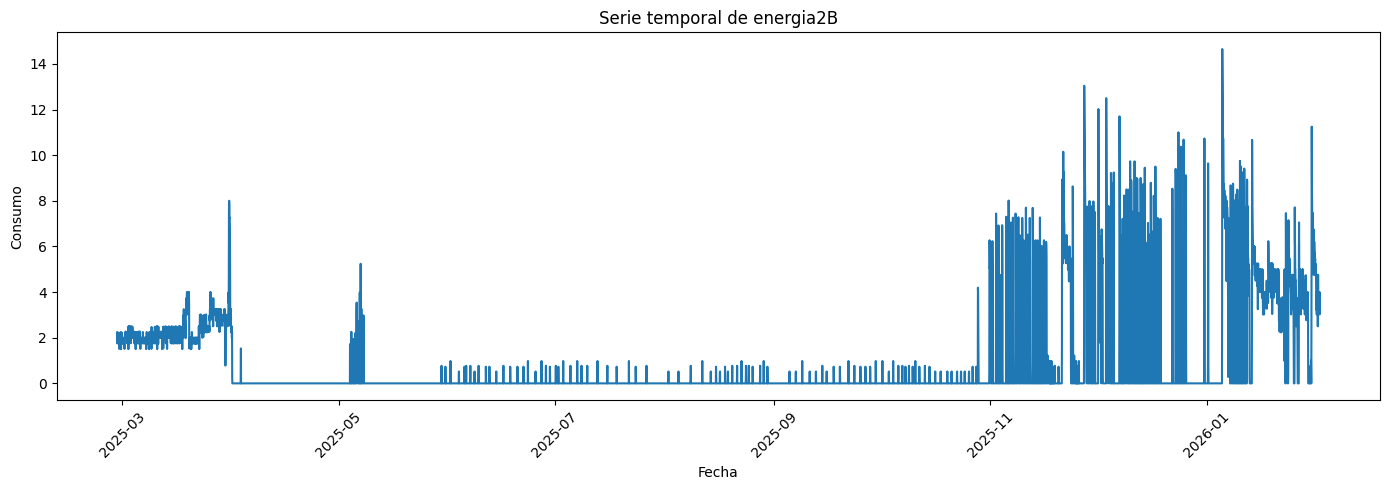

In [7]:
plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff["energiaBB"])
plt.title("Serie temporal de energia2B")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

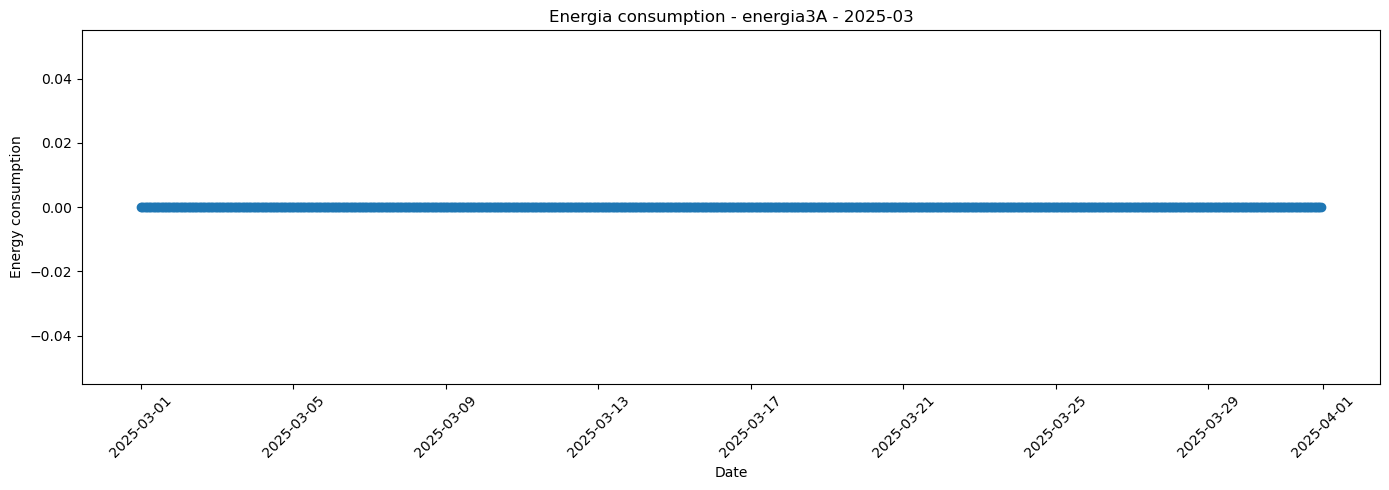

In [55]:
plot_month_apartment(df_energia_diff, df_agua_diff,month=3)

# Modelos de predicción de consumo 

In [8]:
# Nos quedamos solo con energía, no agua
df_train = df_energia_diff.copy()

# Si quieres, evita negativos raros tras diff
for col in cols_pisos_energia:
    df_train[col] = df_train[col].clip(lower=0)

# %%
# Pasar a formato largo: una fila = una hora de una vivienda
df_long = df_train.melt(
    id_vars="fecha",
    value_vars=cols_pisos_energia,
    var_name="vivienda",
    value_name="consumo"
)

df_long = df_long.dropna().copy()
df_long = df_long.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

df_long.head()

# Variables temporales
df_long["hour"] = df_long["fecha"].dt.hour
df_long["dayofweek"] = df_long["fecha"].dt.dayofweek
df_long["day"] = df_long["fecha"].dt.day
df_long["month"] = df_long["fecha"].dt.month
df_long["is_weekend"] = (df_long["dayofweek"] >= 5).astype(int)

#### Train, val and test split- 70% train, 15% valid, 15% test

In [ ]:
# Lags por vivienda
df_long["lag_1"] = df_long.groupby("vivienda")["consumo"].shift(1)
df_long["lag_24"] = df_long.groupby("vivienda")["consumo"].shift(24)
df_long["lag_168"] = df_long.groupby("vivienda")["consumo"].shift(168)

# %%
# Medias móviles por vivienda
df_long["rolling_24"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

df_long["rolling_168"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(168).mean())
)
# Codificar vivienda como número
le = LabelEncoder()
df_long["vivienda_id"] = le.fit_transform(df_long["vivienda"])

# Eliminar filas con nulos generados por lags/rolling
df_model = df_long.dropna().copy()

print("Shape final del dataset de entrenamiento:", df_model.shape)
df_model.head()

# División temporal: 70% train, 15% valid, 15% test
fechas_ordenadas = np.array(sorted(df_model["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train = df_model[df_model["fecha"] <= train_end].copy()
valid = df_model[(df_model["fecha"] > train_end) & (df_model["fecha"] <= valid_end)].copy()
test = df_model[df_model["fecha"] > valid_end].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)
print("Test:", test.shape)


Shape final del dataset de entrenamiento: (87780, 14)
Train: (61457, 14)
Valid: (13167, 14)
Test: (13156, 14)


### Modelo 1: modelo XGBoost

In [10]:
features = [
    # "vivienda_id",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_24",
    "rolling_168"
]

target = "consumo"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

# %%
model1 = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model1.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# Predicción en test
y_pred = model1.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


# Guardar resultados
results = test[["fecha", "vivienda", "consumo"]].copy()
results["pred"] = y_pred

model1.save_model("../models/model1.json")

results.head()

MAE: 0.4796160015164177
RMSE: 1.108359779968516


,fecha,vivienda,consumo,pred
6952,2025-12-14 04:00:00,energia1C,0.00,0.198447
6953,2025-12-14 05:00:00,energia1C,0.00,0.215411
6954,2025-12-14 06:00:00,energia1C,0.00,0.224333
6955,2025-12-14 07:00:00,energia1C,0.00,0.230490
6956,2025-12-14 08:00:00,energia1C,1.42,0.231495


In [33]:
y_pred_train = model1.predict(X_train)
y_pred_test = model1.predict(X_test)

metricas = {}
# Guardar métricas en diccionario
metricas = guardar_metricas_modelo(
    nombre_modelo="Modelo 1: XGBoost base",
    y_train=y_train,
    y_pred_train=y_pred_train,
    y_test=y_test,
    y_pred_test=y_pred_test,
    metricas_modelos=metricas
)

print(metricas)

print(type(metricas))

ValueError: Feature shape mismatch, expected: 10, got 168

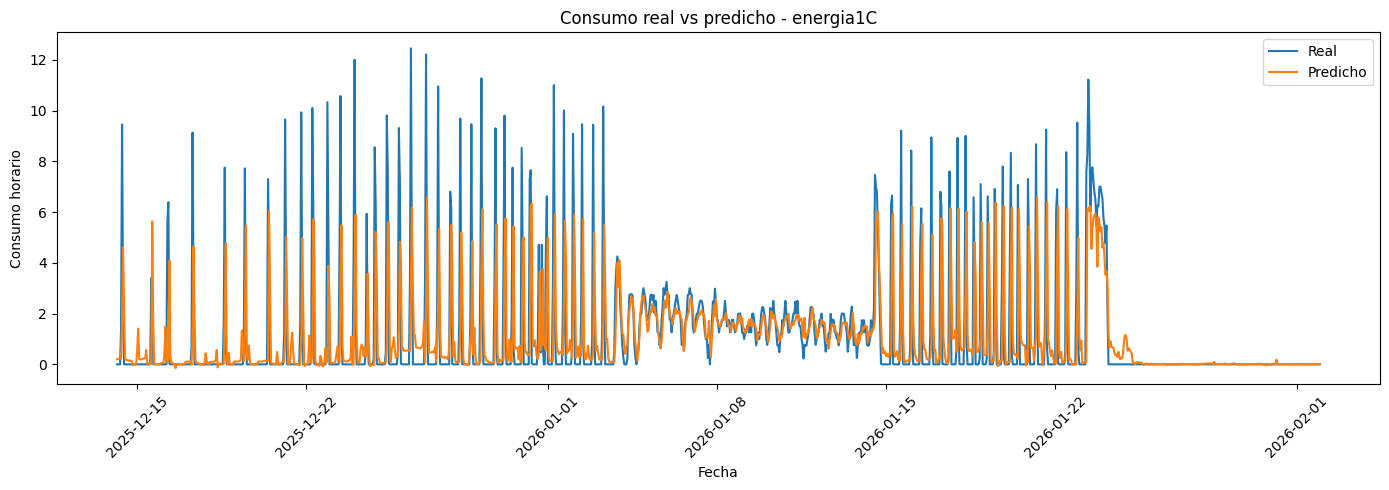

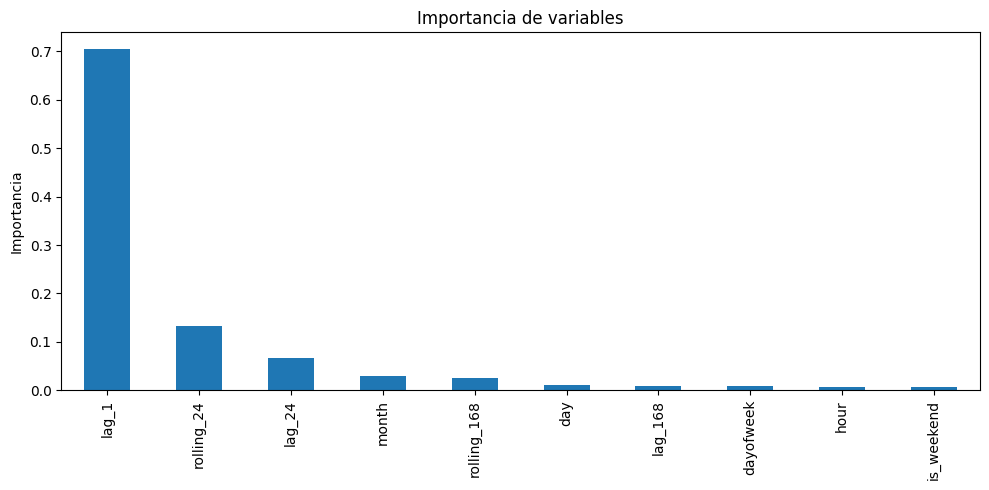

In [12]:
# Visualizar una vivienda concreta
vivienda_ejemplo = "energia1C"   # cambia esto por la que quieras

r = results[results["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14,5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Importancia de variables
importancias = pd.Series(model1.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

In [61]:
# for vivienda in results["vivienda"].unique():
#     r = results[results["vivienda"] == vivienda].copy()

#     plt.figure(figsize=(14,5))
#     plt.plot(r["fecha"], r["consumo"], label="Real")
#     plt.plot(r["fecha"], r["pred"], label="Predicho")
#     plt.title(f"Consumo real vs predicho - {vivienda}")
#     plt.xlabel("Fecha")
#     plt.ylabel("Consumo horario")
#     plt.legend()
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

### Modelo 2: XGBoost con más lags

In [13]:
# Variables temporales
df_long["hour"] = df_long["fecha"].dt.hour
df_long["dayofweek"] = df_long["fecha"].dt.dayofweek
df_long["day"] = df_long["fecha"].dt.day
df_long["month"] = df_long["fecha"].dt.month
df_long["is_weekend"] = (df_long["dayofweek"] >= 5).astype(int)

# Lags por vivienda
df_long["lag_1"] = df_long.groupby("vivienda")["consumo"].shift(1)
df_long["lag_2"] = df_long.groupby("vivienda")["consumo"].shift(2)
df_long["lag_3"] = df_long.groupby("vivienda")["consumo"].shift(3)
df_long["lag_6"] = df_long.groupby("vivienda")["consumo"].shift(6)
df_long["lag_12"] = df_long.groupby("vivienda")["consumo"].shift(12)
df_long["lag_24"] = df_long.groupby("vivienda")["consumo"].shift(24)
df_long["lag_48"] = df_long.groupby("vivienda")["consumo"].shift(48)
df_long["lag_72"] = df_long.groupby("vivienda")["consumo"].shift(72)
df_long["lag_168"] = df_long.groupby("vivienda")["consumo"].shift(168)

# Medias móviles por vivienda
df_long["rolling_6"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(6).mean())
)

df_long["rolling_24"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

df_long["rolling_168"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(168).mean())
)

# Codificar vivienda como número
le = LabelEncoder()
df_long["vivienda_id"] = le.fit_transform(df_long["vivienda"])

# Eliminar filas con nulos generados por lags/rolling
df_model = df_long.dropna().copy()

print("Shape final del dataset de entrenamiento:", df_model.shape)
df_model.head()

# División temporal: 70% train, 15% valid, 15% test
fechas_ordenadas = np.array(sorted(df_model["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train = df_model[df_model["fecha"] <= train_end].copy()
valid = df_model[(df_model["fecha"] > train_end) & (df_model["fecha"] <= valid_end)].copy()
test = df_model[df_model["fecha"] > valid_end].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)
print("Test:", test.shape)

features = [
    # "vivienda_id",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    # "lag_6",
    # "lag_12",
    "lag_24",
    # "lag_48",
    # "lag_72",
    "lag_168",
    "rolling_6",
    "rolling_24",
    "rolling_168"
]

target = "consumo"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]



model2 = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model2.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)


# Predicción en test
y_pred = model2.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# Guardar resultados
results2 = test[["fecha", "vivienda", "consumo"]].copy()
results2["pred"] = y_pred

model2.save_model("../models/model2.json")
results2.head()


Shape final del dataset de entrenamiento: (87780, 21)
Train: (61457, 21)
Valid: (13167, 21)
Test: (13156, 21)
MAE: 0.43804657431757077
RMSE: 1.0813892204224498


,fecha,vivienda,consumo,pred
6952,2025-12-14 04:00:00,energia1C,0.00,0.034515
6953,2025-12-14 05:00:00,energia1C,0.00,0.034515
6954,2025-12-14 06:00:00,energia1C,0.00,0.034515
6955,2025-12-14 07:00:00,energia1C,0.00,0.034515
6956,2025-12-14 08:00:00,energia1C,1.42,0.034515


In [14]:
y_pred_train = model2.predict(X_train)
y_pred_test = model2.predict(X_test)

metricas= guardar_metricas_modelo(
    nombre_modelo="Modelo2: XGBoost con más lags",
    y_train=y_train,
    y_pred_train=y_pred_train,
    y_test=y_test,
    y_pred_test=y_pred_test, 
    metricas_modelos=metricas
)

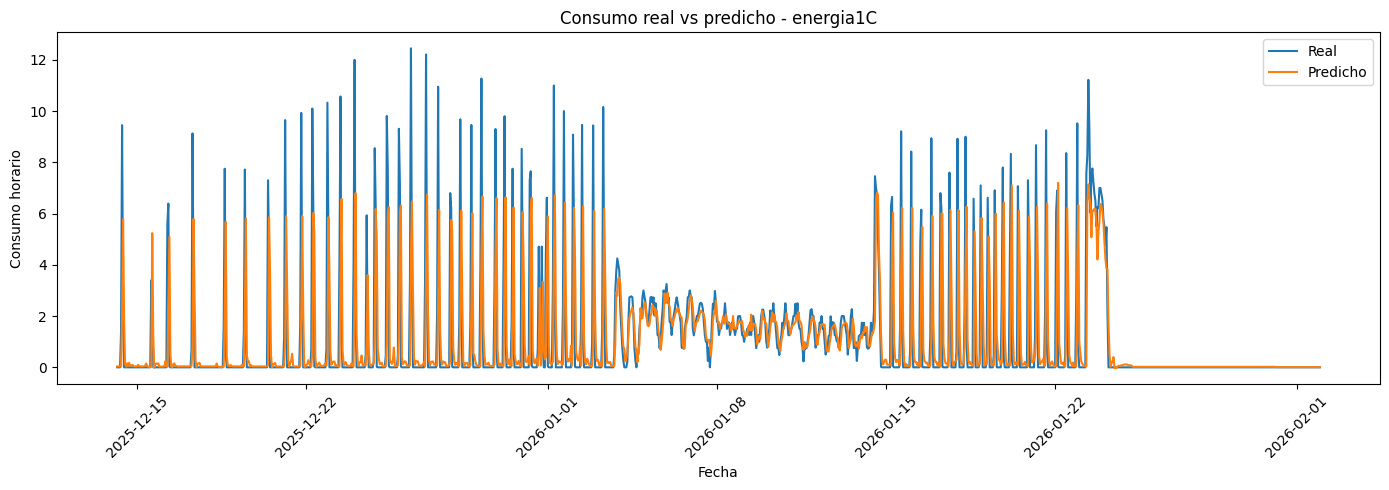

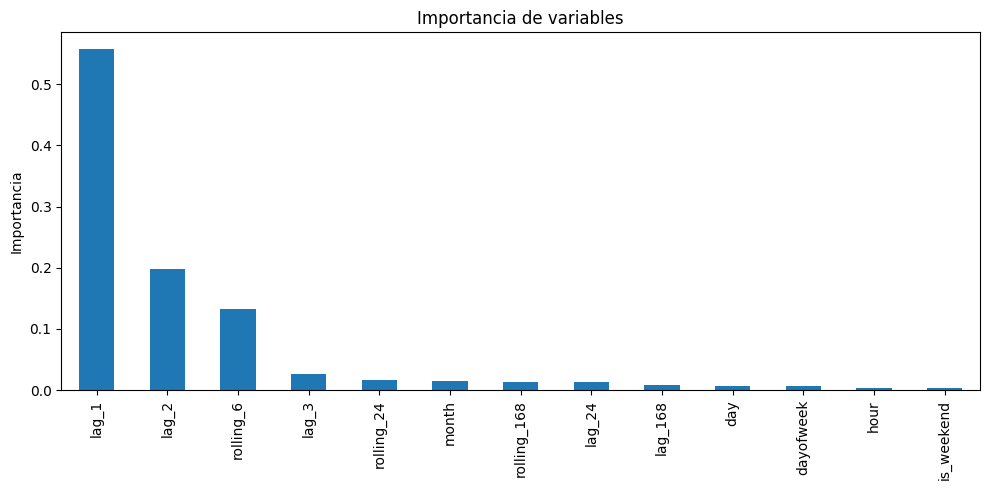

In [16]:

# Visualizar una vivienda concreta
vivienda_ejemplo = "energia1C"   # cambia esto por la que quieras

r = results2[results2["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14,5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %%
# Importancia de variables
importancias = pd.Series(model2.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

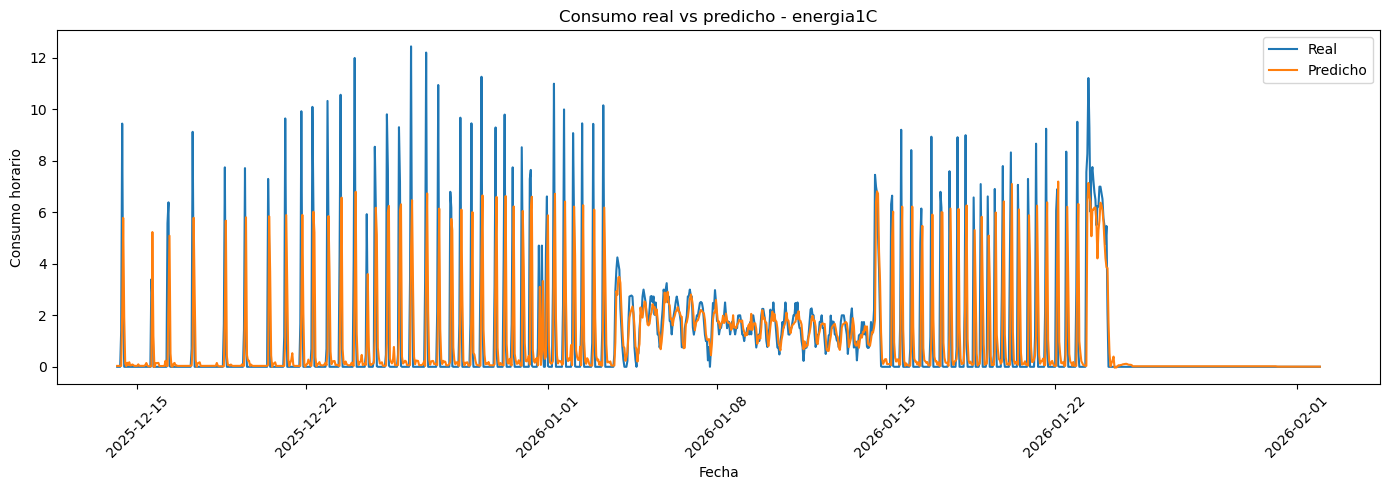

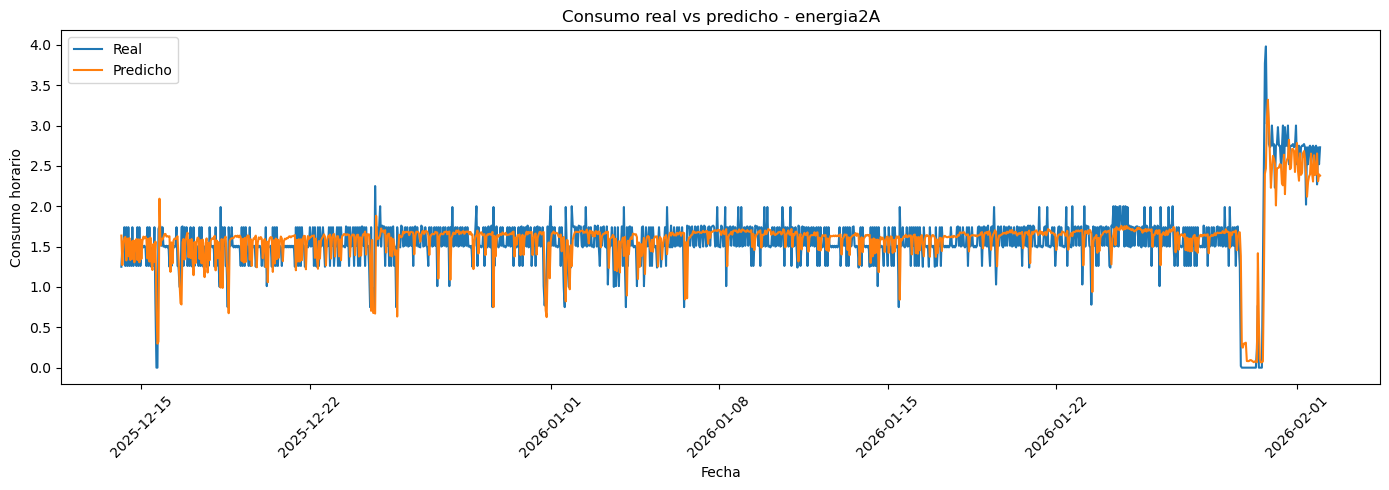

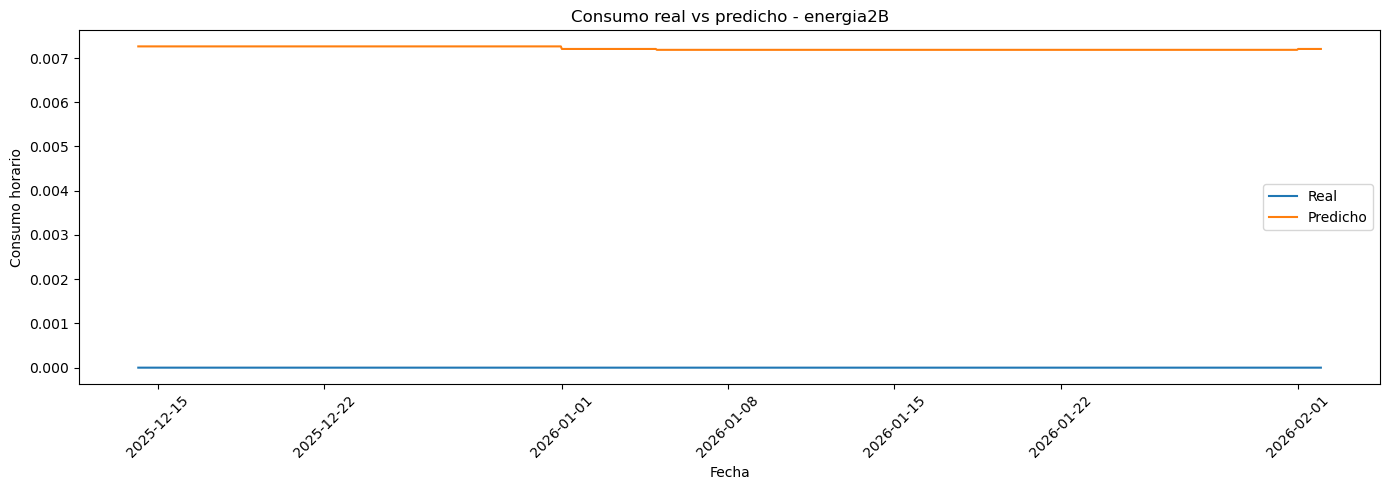

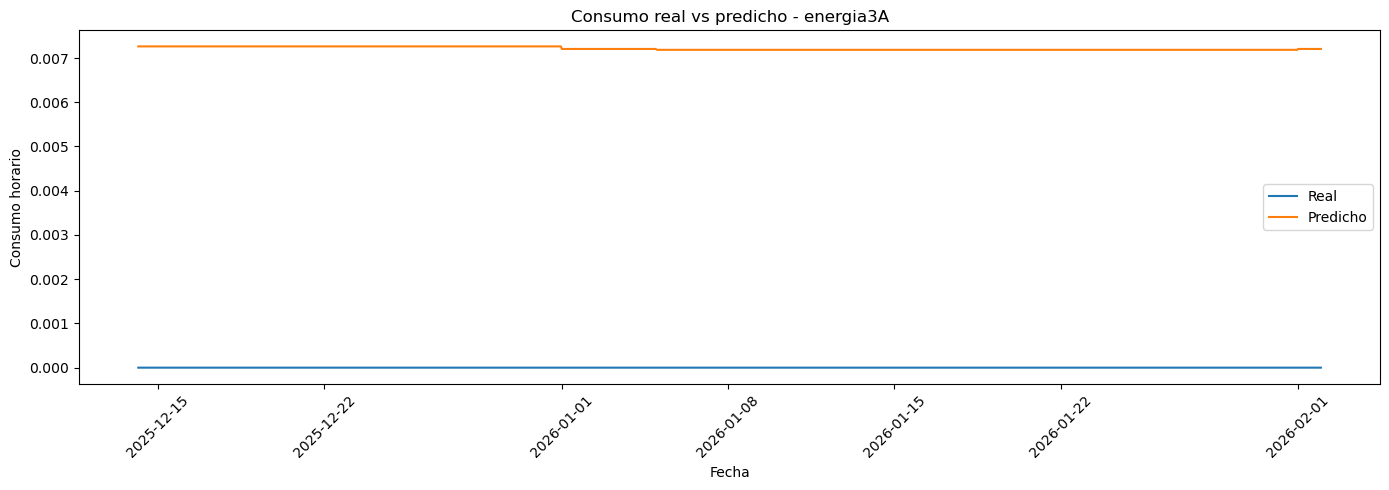

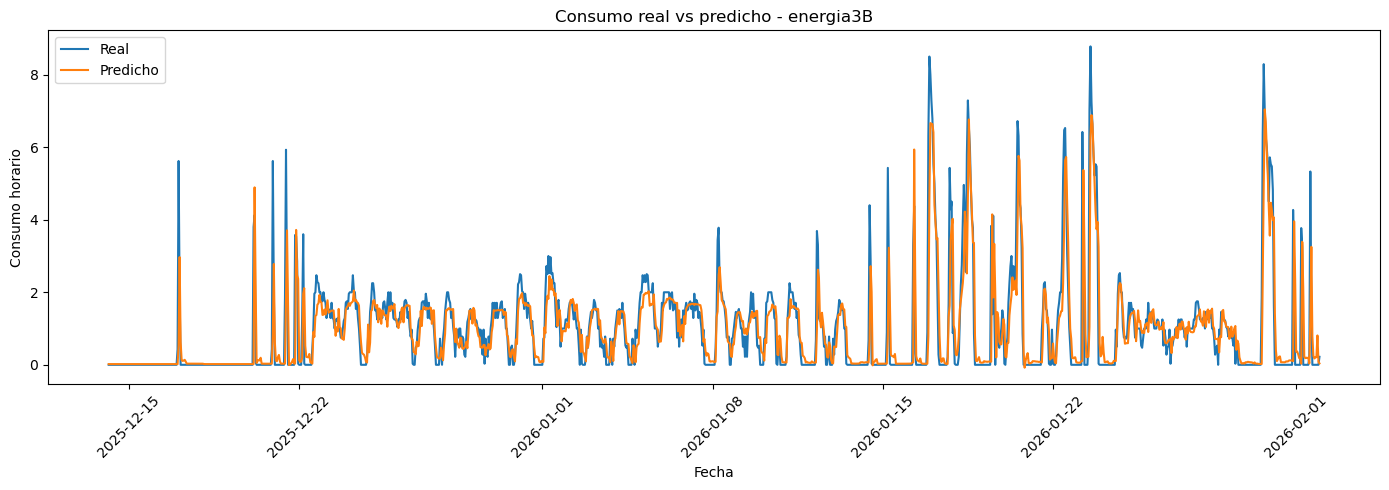

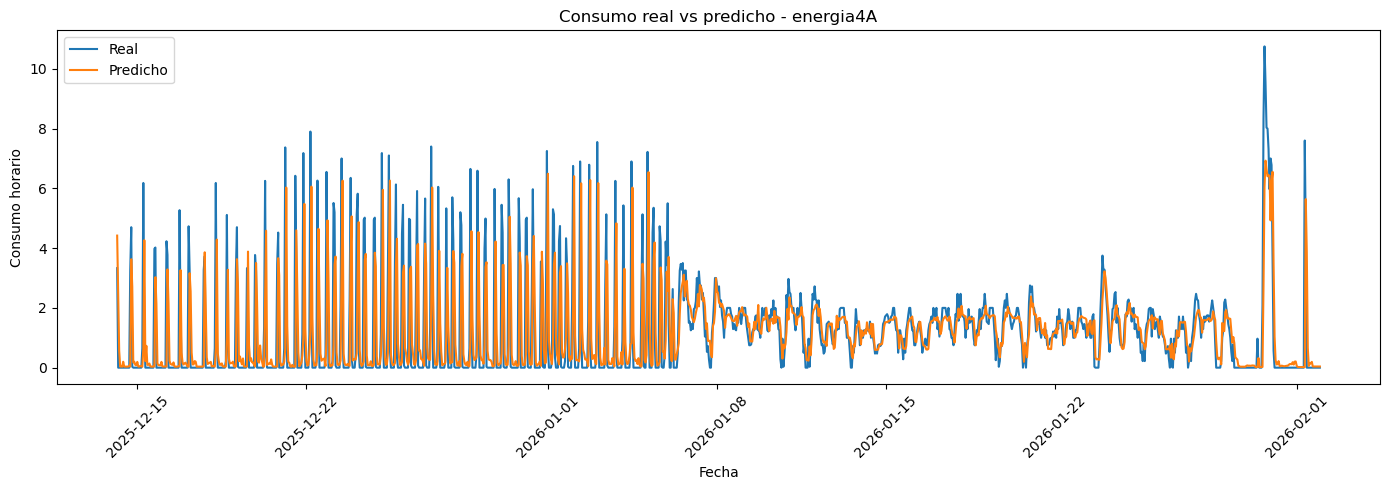

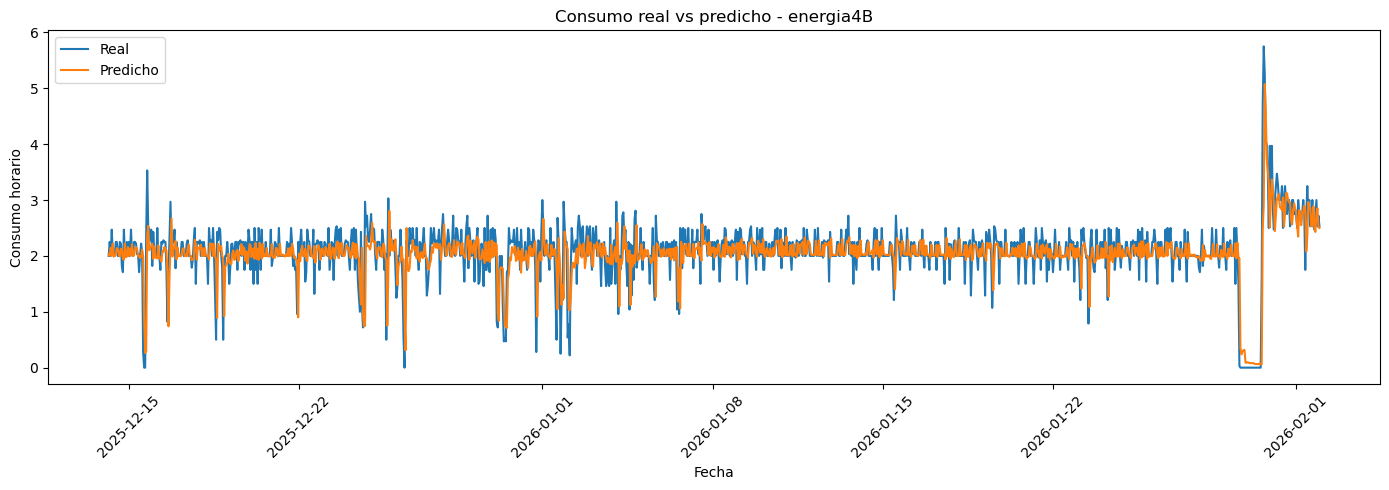

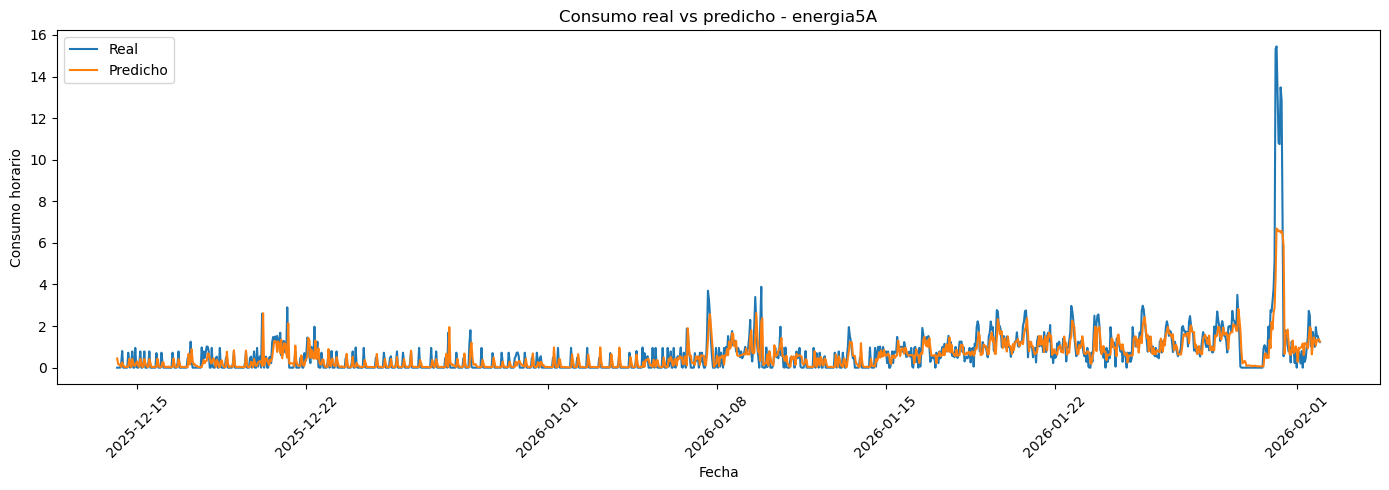

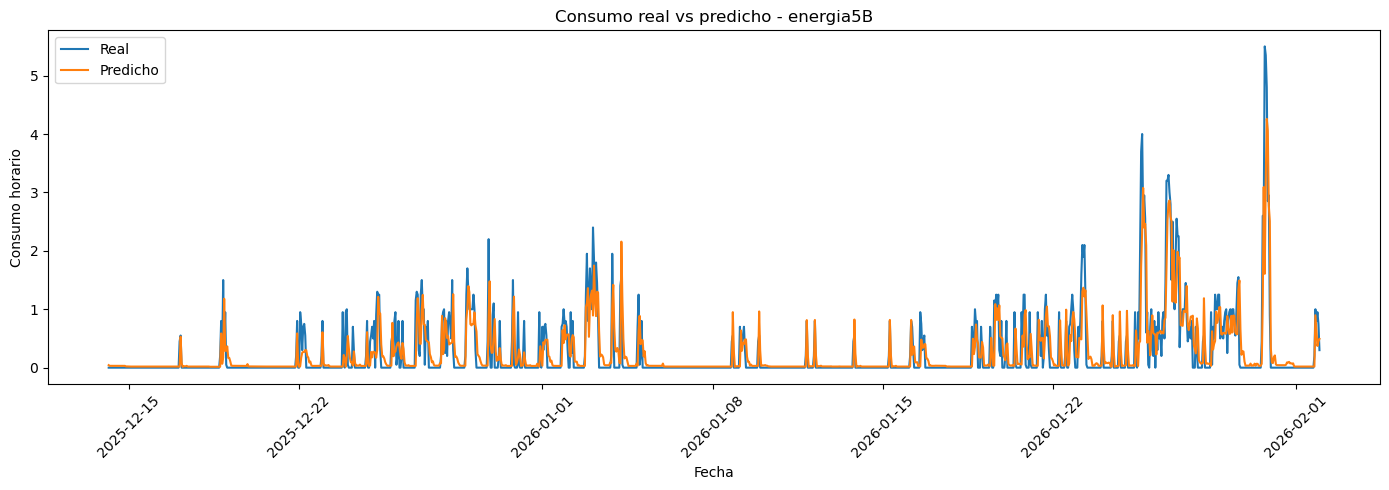

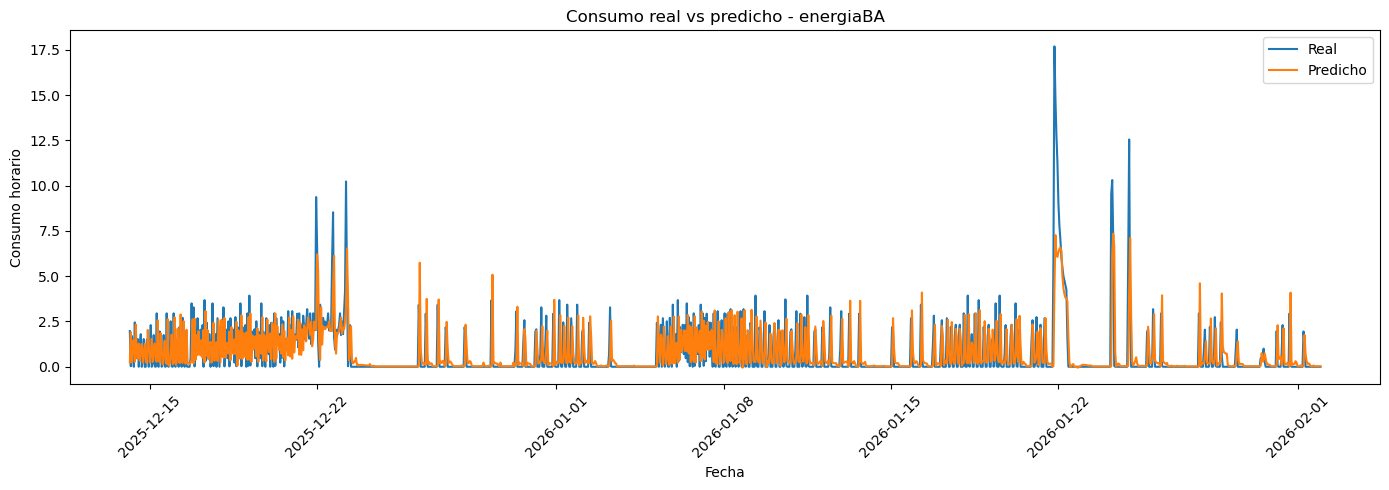

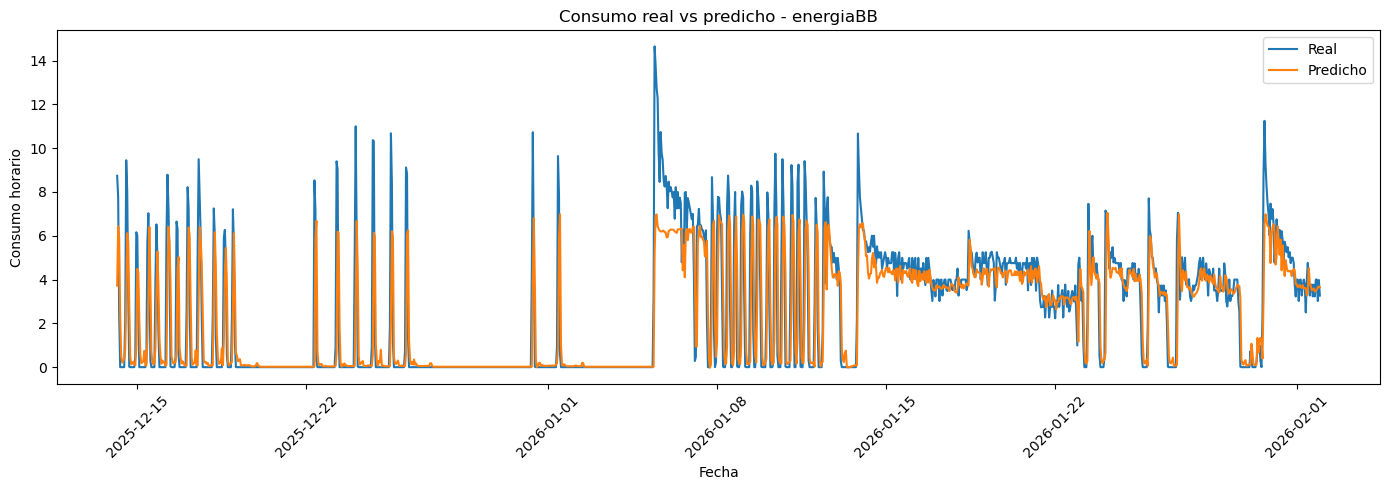

In [ ]:
# for vivienda in results2["vivienda"].unique():
#     r = results2[results2["vivienda"] == vivienda].copy()

#     plt.figure(figsize=(14,5))
#     plt.plot(r["fecha"], r["consumo"], label="Real")
#     plt.plot(r["fecha"], r["pred"], label="Predicho")
#     plt.title(f"Consumo real vs predicho - {vivienda}")
#     plt.xlabel("Fecha")
#     plt.ylabel("Consumo horario")
#     plt.legend()
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

### Modelo 3: Modelo 2 + variable de temperatura 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. PREPARAR BASE DE ENERGÍA
# =========================================================
# Nos quedamos solo con energía, no agua
df_train = df_energia_diff.copy()

# Evitar negativos raros tras diff
for col in cols_pisos_energia:
    df_train[col] = df_train[col].clip(lower=0)

# Pasar a formato largo: una fila = una hora de una vivienda
df_long = df_train.melt(
    id_vars="fecha",
    value_vars=cols_pisos_energia,
    var_name="vivienda",
    value_name="consumo"
)

df_long = df_long.dropna().copy()
df_long = df_long.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

# =========================================================
# 2. DESCARGAR TEMPERATURA HISTÓRICA
# =========================================================
start_date = df_long["fecha"].min().strftime("%Y-%m-%d")
end_date = df_long["fecha"].max().strftime("%Y-%m-%d")

# Coordenadas de la casa en claudio coello
latitude = 40.4245
longitude = -3.6870

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m",
    "timezone": "Europe/Madrid"
}

response = requests.get(url, params=params, timeout=60)
response.raise_for_status()
weather_json = response.json()

df_temp = pd.DataFrame({
    "fecha": pd.to_datetime(weather_json["hourly"]["time"]),
    "temp": weather_json["hourly"]["temperature_2m"]
})

# =========================================================
# 3. UNIR TEMPERATURA
# =========================================================
df_long = df_long.merge(df_temp, on="fecha", how="left")

# =========================================================
# 4. VARIABLES TEMPORALES
# =========================================================
df_long["hour"] = df_long["fecha"].dt.hour
df_long["dayofweek"] = df_long["fecha"].dt.dayofweek
df_long["day"] = df_long["fecha"].dt.day
df_long["month"] = df_long["fecha"].dt.month
df_long["is_weekend"] = (df_long["dayofweek"] >= 5).astype(int)

# =========================================================
# 5. LAGS DE CONSUMO POR VIVIENDA
# =========================================================
df_long["lag_1"] = df_long.groupby("vivienda")["consumo"].shift(1)
df_long["lag_2"] = df_long.groupby("vivienda")["consumo"].shift(2)
df_long["lag_3"] = df_long.groupby("vivienda")["consumo"].shift(3)
df_long["lag_24"] = df_long.groupby("vivienda")["consumo"].shift(24)
df_long["lag_168"] = df_long.groupby("vivienda")["consumo"].shift(168)

# =========================================================
# 6. ROLLING DE CONSUMO POR VIVIENDA
# =========================================================
df_long["rolling_6"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(6).mean())
)

df_long["rolling_24"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

df_long["rolling_168"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(168).mean())
)

# =========================================================
# 7. FEATURES DE TEMPERATURA
# =========================================================
df_long["temp_lag_1"] = df_long.groupby("vivienda")["temp"].shift(1)
df_long["temp_lag_24"] = df_long.groupby("vivienda")["temp"].shift(24)

df_long["temp_rolling_24"] = (
    df_long.groupby("vivienda")["temp"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

# =========================================================
# 8. CODIFICAR VIVIENDA
# =========================================================
le = LabelEncoder()
df_long["vivienda_id"] = le.fit_transform(df_long["vivienda"])

# =========================================================
# 9. ELIMINAR NULOS
# =========================================================
df_model = df_long.dropna().copy()

print("Shape final del dataset de entrenamiento:", df_model.shape)
# print(df_model.head())

# =========================================================
# 10. DIVISIÓN TEMPORAL
# =========================================================
fechas_ordenadas = np.array(sorted(df_model["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train = df_model[df_model["fecha"] <= train_end].copy()
valid = df_model[(df_model["fecha"] > train_end) & (df_model["fecha"] <= valid_end)].copy()
test = df_model[df_model["fecha"] > valid_end].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)
print("Test:", test.shape)

# =========================================================
# 11. FEATURES Y TARGET
# =========================================================
features = [
    # "vivienda_id",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_168",
    "rolling_6",
    "rolling_24",
    "rolling_168",
    "temp",
    "temp_lag_1",
    "temp_lag_24",
    "temp_rolling_24"
]

target = "consumo"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

# =========================================================
# 12. ENTRENAR MODELO
# =========================================================
model_temp = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model_temp.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# =========================================================
# 13. PREDICCIÓN
# =========================================================
y_pred = model_temp.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# =========================================================
# 14. GUARDAR RESULTADOS
# =========================================================
results_temp = test[["fecha", "vivienda", "consumo"]].copy()
results_temp["pred"] = y_pred
model_temp.save_model("../models/model3.json")
print(results_temp.head())

Shape final del dataset de entrenamiento: (87780, 21)
Train: (61457, 21)
Valid: (13167, 21)
Test: (13156, 21)
MAE: 0.4591515473007066
RMSE: 1.076414098090734
                   fecha   vivienda  consumo      pred
6952 2025-12-14 04:00:00  energia1C     0.00  0.037201
6953 2025-12-14 05:00:00  energia1C     0.00  0.037201
6954 2025-12-14 06:00:00  energia1C     0.00  0.037201
6955 2025-12-14 07:00:00  energia1C     0.00  0.037201
6956 2025-12-14 08:00:00  energia1C     1.42  0.037201


In [18]:
y_pred_train = model_temp.predict(X_train)
y_pred_test = model_temp.predict(X_test)

metricas = guardar_metricas_modelo(
    nombre_modelo="Modelo3: XGBoost + temperatura",
    y_train=y_train,
    y_pred_train=y_pred_train,
    y_test=y_test,
    y_pred_test=y_pred_test, 
    metricas_modelos=metricas
)

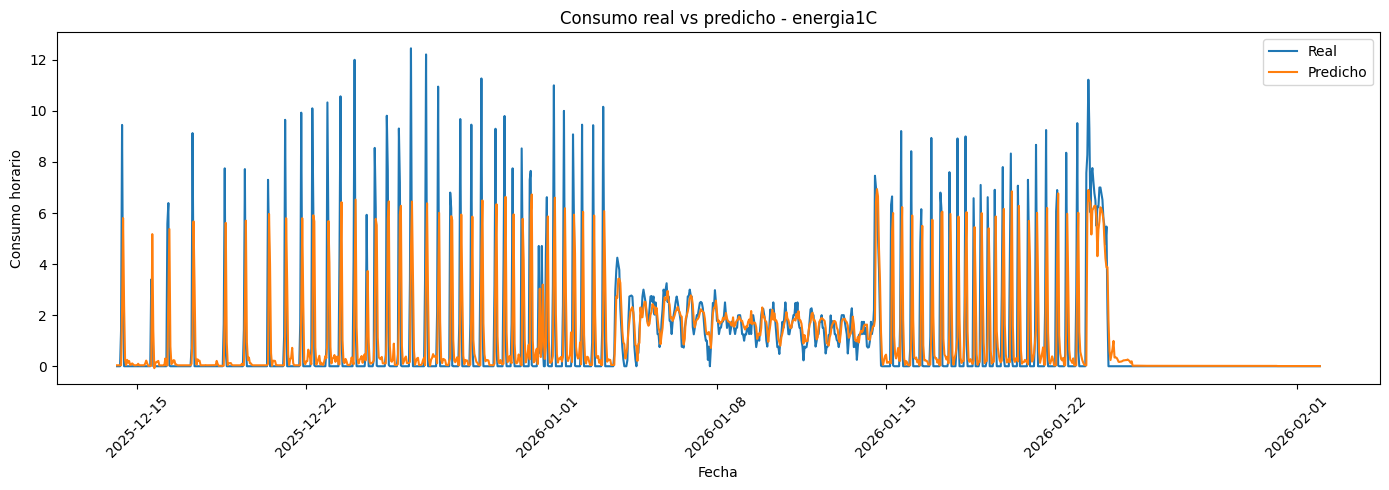

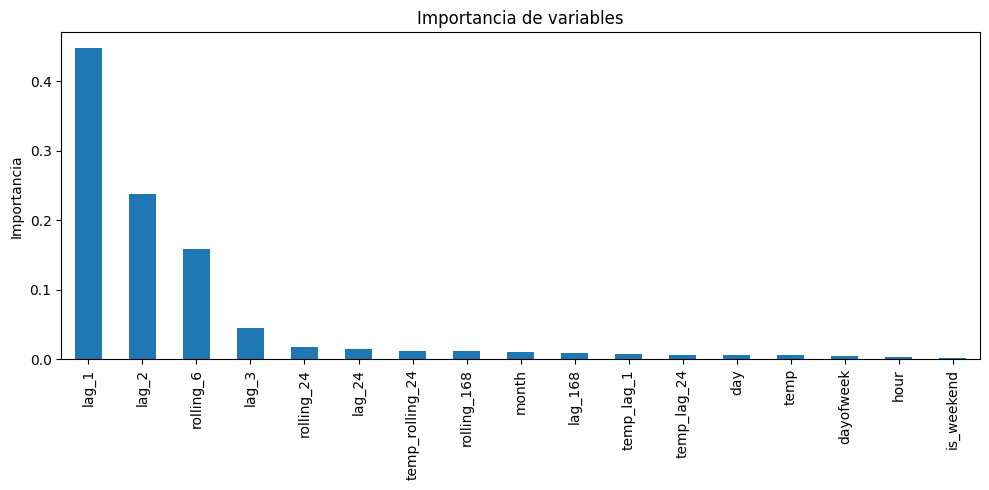

                MAE      RMSE
vivienda                     
energia2B  0.007794  0.007795
energia3A  0.007794  0.007795
energia5B  0.209898  0.381866
energia2A  0.225176  0.298490
energia4B  0.278049  0.406051
energia5A  0.413878  0.771829
energia3B  0.419656  0.787877
energia4A  0.803124  1.482376
energiaBB  0.872788  1.691157
energiaBA  0.899397  1.470530
energia1C  0.913112  1.977130


C:\Users\laugo\AppData\Local\Temp\ipykernel_29404\3719432201.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [19]:
# =========================================================
# 15. VISUALIZAR UNA VIVIENDA
# =========================================================
vivienda_ejemplo = "energia1C"

r = results_temp[results_temp["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14, 5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 16. IMPORTANCIA DE VARIABLES
# =========================================================
importancias = pd.Series(model_temp.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

# =========================================================
# 17. MÉTRICAS POR VIVIENDA
# =========================================================
metricas_por_vivienda = (
    results_temp.groupby("vivienda")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["consumo"], g["pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["consumo"], g["pred"]))
    }))
    .sort_values("MAE")
)

print(metricas_por_vivienda)

In [20]:
# Predicción en test
y_pred = model_temp.predict(X_test)

# Métricas globales
mae_total = mean_absolute_error(y_test, y_pred)
rmse_total = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE total:", mae_total)
print("RMSE total:", rmse_total)

MAE total: 0.4591515473007066
RMSE total: 1.076414098090734


### Modelo 4: BiLSTM

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# =========================================================
# 1. PARTIR DE df_long YA CREADO
# Debe tener al menos:
# fecha, vivienda, consumo
# =========================================================

df_bilstm = df_long[["fecha", "vivienda", "consumo"]].copy()
df_bilstm = df_bilstm.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

# =========================================================
# 2. SPLIT TEMPORAL GLOBAL
# =========================================================
fechas_ordenadas = np.array(sorted(df_bilstm["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train_df = df_bilstm[df_bilstm["fecha"] <= train_end].copy()
valid_df = df_bilstm[(df_bilstm["fecha"] > train_end) & (df_bilstm["fecha"] <= valid_end)].copy()
test_df  = df_bilstm[df_bilstm["fecha"] > valid_end].copy()

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

# =========================================================
# 3. ESCALAR SOLO CON TRAIN
# =========================================================
scaler = StandardScaler()
scaler.fit(train_df[["consumo"]])

train_df["consumo_scaled"] = scaler.transform(train_df[["consumo"]])
valid_df["consumo_scaled"] = scaler.transform(valid_df[["consumo"]])
test_df["consumo_scaled"]  = scaler.transform(test_df[["consumo"]])

# =========================================================
# 4. CREAR SECUENCIAS POR VIVIENDA
# =========================================================
SEQ_LEN = 24 * 7  # última semana para predecir la siguiente hora

def make_sequences(df_part, seq_len=SEQ_LEN):
    X, y, fechas, viviendas = [], [], [], []

    for vivienda, g in df_part.groupby("vivienda"):
        g = g.sort_values("fecha").reset_index(drop=True)
        values = g["consumo_scaled"].values
        raw_values = g["consumo"].values
        fechas_g = g["fecha"].values

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            X.append(values[i-seq_len:i])
            y.append(values[i])  # target escalado
            fechas.append(fechas_g[i])
            viviendas.append(vivienda)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    fechas = np.array(fechas)
    viviendas = np.array(viviendas)

    return X, y, fechas, viviendas

X_train, y_train, fechas_train, viv_train = make_sequences(train_df)
X_valid, y_valid, fechas_valid, viv_valid = make_sequences(valid_df)
X_test,  y_test,  fechas_test,  viv_test  = make_sequences(test_df)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

# =========================================================
# 5. DATASET / DATALOADER
# =========================================================
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SeqDataset(X_train, y_train)
valid_ds = SeqDataset(X_valid, y_valid)
test_ds  = SeqDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# =========================================================
# 6. MODELO BiLSTM
# =========================================================
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # última salida temporal
        out = self.fc(out)
        return out.squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bilstm = BiLSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_bilstm.parameters(), lr=0.001)

# =========================================================
# 7. ENTRENAMIENTO
# =========================================================
EPOCHS = 10
best_valid_loss = float("inf")
best_state = None

for epoch in range(EPOCHS):
    model_bilstm.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model_bilstm(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model_bilstm.eval()
    valid_losses = []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model_bilstm(xb)
            loss = criterion(pred, yb)
            valid_losses.append(loss.item())

    mean_train = np.mean(train_losses)
    mean_valid = np.mean(valid_losses)

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {mean_train:.4f} - valid_loss: {mean_valid:.4f}")

    if mean_valid < best_valid_loss:
        best_valid_loss = mean_valid
        best_state = model_bilstm.state_dict()

# cargar mejor modelo
model_bilstm.load_state_dict(best_state)

# =========================================================
# 8. EVALUACIÓN EN TEST
# =========================================================
model_bilstm.eval()
preds_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model_bilstm(xb).cpu().numpy()
        preds_scaled.extend(pred)

preds_scaled = np.array(preds_scaled)

# desescalar
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
preds_real  = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

mae_bilstm = mean_absolute_error(y_test_real, preds_real)
rmse_bilstm = np.sqrt(mean_squared_error(y_test_real, preds_real))

print("BiLSTM MAE:", mae_bilstm)
print("BiLSTM RMSE:", rmse_bilstm)

# =========================================================
# 9. RESULTADOS
# =========================================================
results_bilstm = pd.DataFrame({
    "fecha": fechas_test,
    "vivienda": viv_test,
    "consumo": y_test_real,
    "pred": preds_real
})

print(results_bilstm.head())

torch.save(model_bilstm.state_dict(),  "../models/weights_model4.pth")

# 3. Guardar el ESCALADOR (StandardScaler)
# Esto es VITAL porque el modelo solo entiende datos escalados. 
# Sin esto, tu web no podrá "traducir" los kW reales.
joblib.dump(scaler, "../models/scaler_model4.joblib")
print(f"Modelo BiLSTM y Scaler guardados")


Train: (62744, 3)
Valid: (13442, 3)
Test: (13442, 3)
X_train: (60896, 168) y_train: (60896,)
X_valid: (11594, 168) y_valid: (11594,)
X_test : (11594, 168) y_test : (11594,)
Epoch 1/10 - train_loss: 0.0965 - valid_loss: 1.5764
Epoch 2/10 - train_loss: 0.0778 - valid_loss: 1.5095
Epoch 3/10 - train_loss: 0.0769 - valid_loss: 1.5857
Epoch 4/10 - train_loss: 0.0746 - valid_loss: 1.5347
Epoch 5/10 - train_loss: 0.0733 - valid_loss: 1.5242
Epoch 6/10 - train_loss: 0.0703 - valid_loss: 1.4340
Epoch 7/10 - train_loss: 0.0699 - valid_loss: 1.4920
Epoch 8/10 - train_loss: 0.0696 - valid_loss: 1.3989
Epoch 9/10 - train_loss: 0.0669 - valid_loss: 1.3512
Epoch 10/10 - train_loss: 0.0663 - valid_loss: 1.3423
BiLSTM MAE: 0.44046884775161743
BiLSTM RMSE: 1.1090266795754429
                fecha   vivienda  consumo      pred
0 2025-12-20 02:00:00  energia1C      0.0  0.038062
1 2025-12-20 03:00:00  energia1C      0.0  0.044109
2 2025-12-20 04:00:00  energia1C      0.0  0.030781
3 2025-12-20 05:00:00  e

C:\Users\laugo\AppData\Local\Temp\ipykernel_29404\3743761374.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


                MAE      RMSE
vivienda                     
energia2B  0.003242  0.003242
energia3A  0.003242  0.003242
energia5B  0.205786  0.414445
energia2A  0.214976  0.281520
energia4B  0.292037  0.420444
energia5A  0.373557  0.707852
energia3B  0.430620  0.840381
energiaBA  0.757735  1.386418
energia4A  0.772223  1.552436
energiaBB  0.819939  1.648049
energia1C  0.971800  2.201354


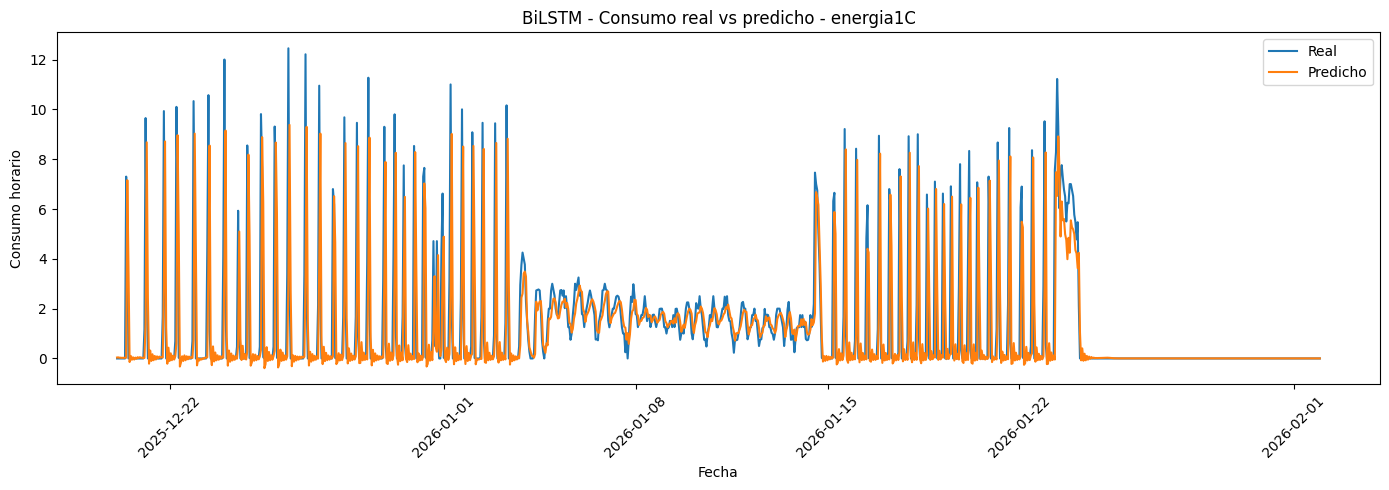

In [23]:
# =========================================================
# 10. MÉTRICAS POR VIVIENDA
# =========================================================
metricas_por_vivienda_bilstm = (
    results_bilstm.groupby("vivienda")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["consumo"], g["pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["consumo"], g["pred"]))
    }))
    .sort_values("MAE")
)

print(metricas_por_vivienda_bilstm)

# =========================================================
# 11. GRÁFICA DE UNA VIVIENDA
# =========================================================
vivienda_ejemplo = "energia1C"

r = results_bilstm[results_bilstm["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14,5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"BiLSTM - Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# =========================================================
# 10. MÉTRICAS TRAIN Y TEST MODELO 4 BiLSTM
# usando guardar_metricas_modelo()
# =========================================================

from sklearn.metrics import r2_score

def predecir_bilstm_loader(model, loader, device):
    model.eval()
    preds_scaled = []
    reales_scaled = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)

            pred = model(xb).cpu().numpy()

            preds_scaled.extend(pred)
            reales_scaled.extend(yb.numpy())

    return np.array(reales_scaled), np.array(preds_scaled)


# Predicciones escaladas en train
y_train_scaled_real, y_train_scaled_pred = predecir_bilstm_loader(
    model_bilstm,
    train_loader,
    device
)

# Predicciones escaladas en test
y_test_scaled_real, y_test_scaled_pred = predecir_bilstm_loader(
    model_bilstm,
    test_loader,
    device
)

# Desescalar train
y_train_real = scaler.inverse_transform(
    y_train_scaled_real.reshape(-1, 1)
).flatten()

y_pred_train_real = scaler.inverse_transform(
    y_train_scaled_pred.reshape(-1, 1)
).flatten()

# Desescalar test
y_test_real = scaler.inverse_transform(
    y_test_scaled_real.reshape(-1, 1)
).flatten()

y_pred_test_real = scaler.inverse_transform(
    y_test_scaled_pred.reshape(-1, 1)
).flatten()

# Crear diccionario si no existe
try:
    metricas_modelos
except NameError:
    metricas_modelos = {}

# Guardar métricas usando tu función
metricas = guardar_metricas_modelo(
    nombre_modelo="BiLSTM",
    y_train=y_train_real,
    y_pred_train=y_pred_train_real,
    y_test=y_test_real,
    y_pred_test=y_pred_test_real,
    metricas_modelos= metricas
)


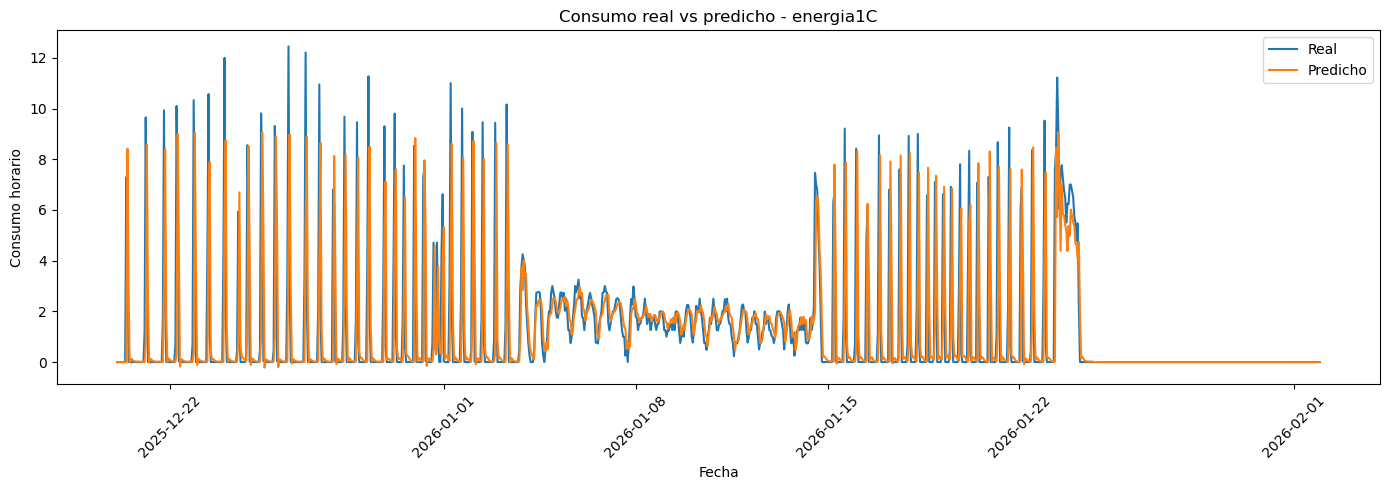

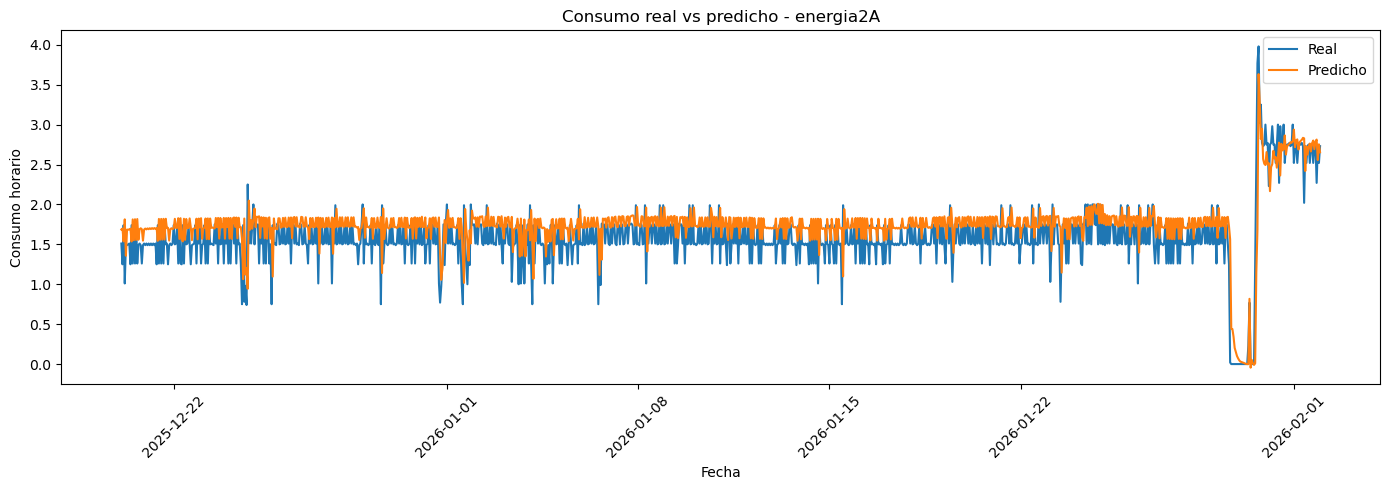

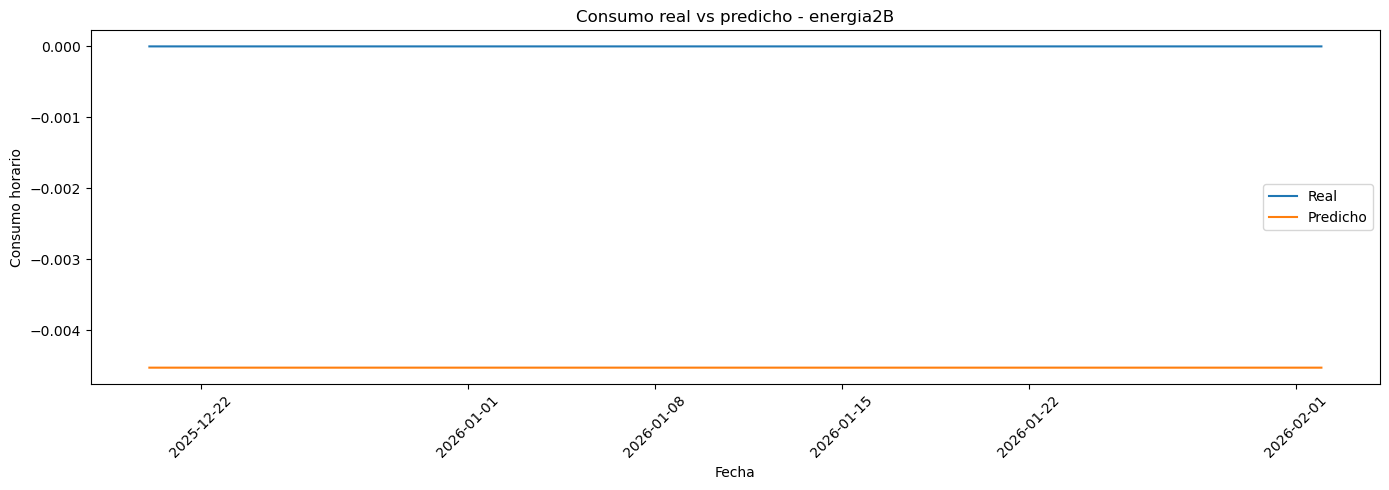

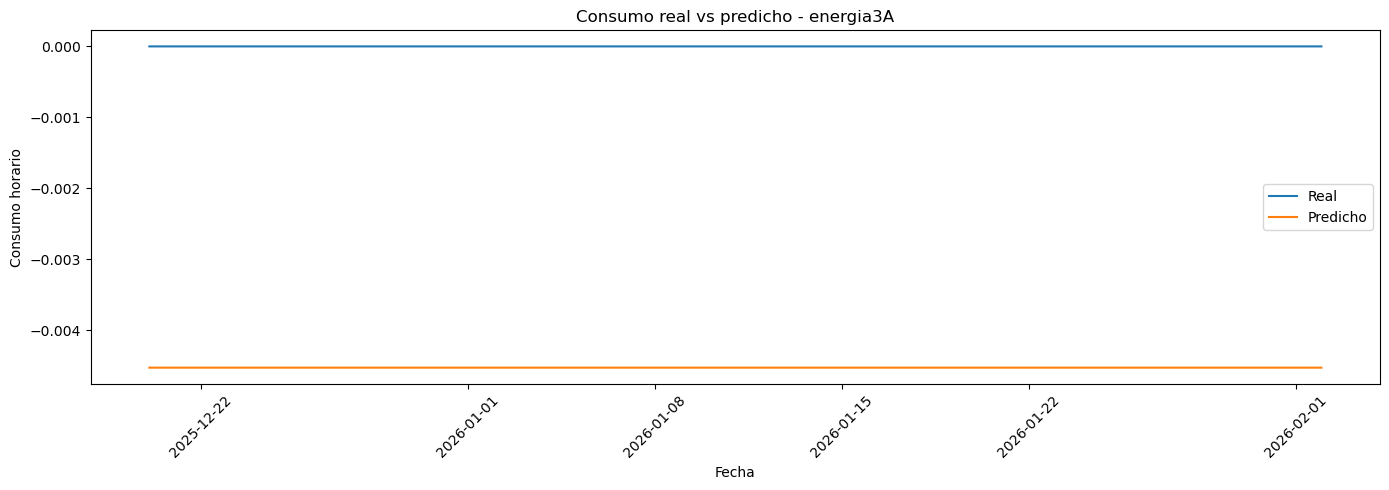

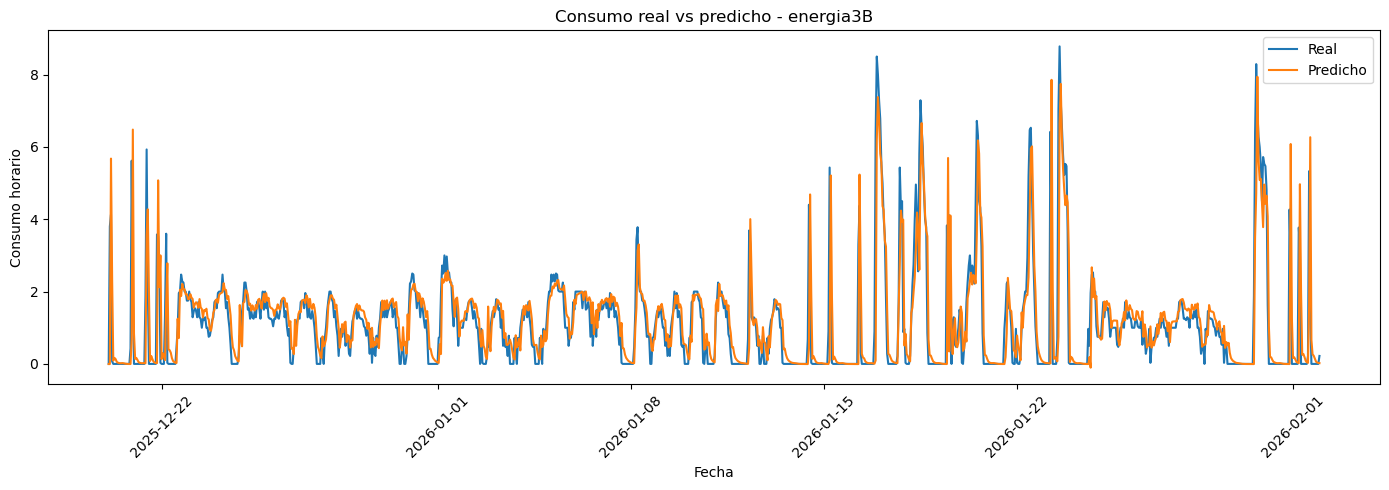

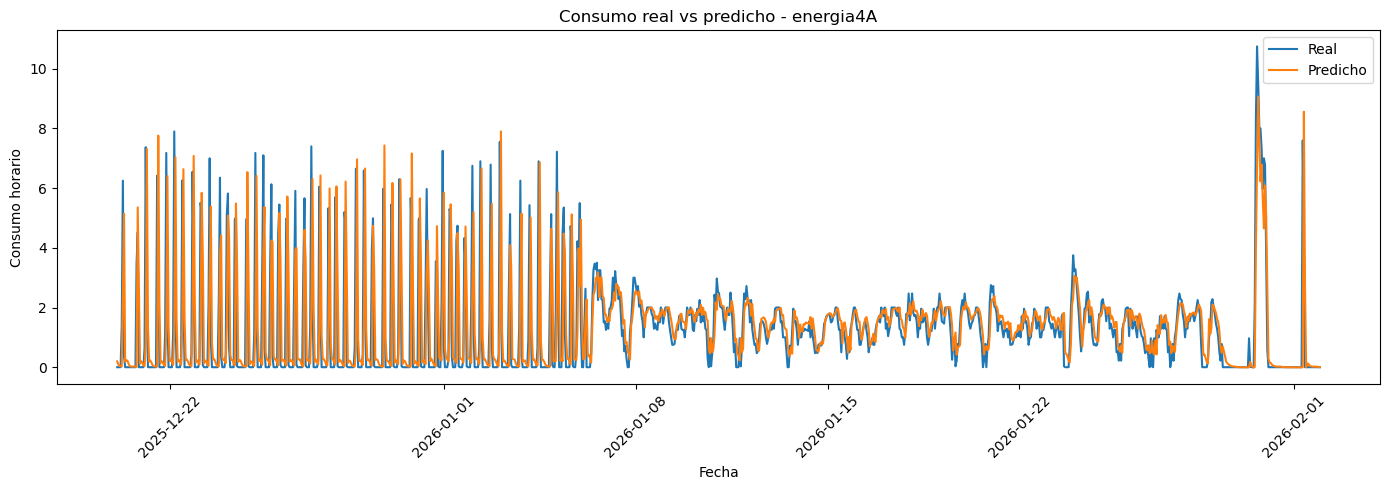

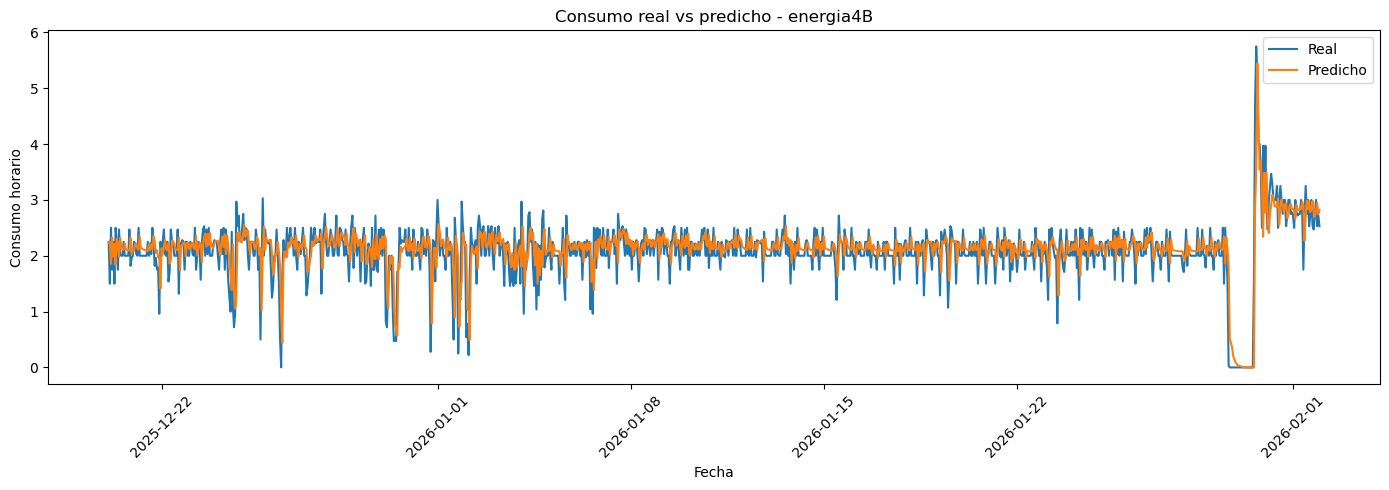

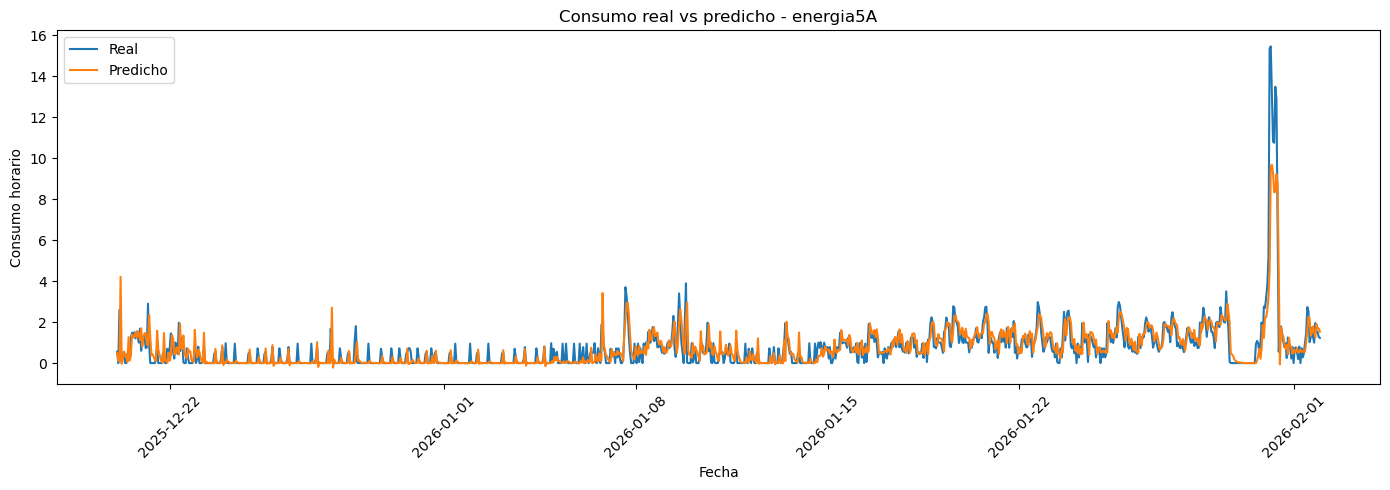

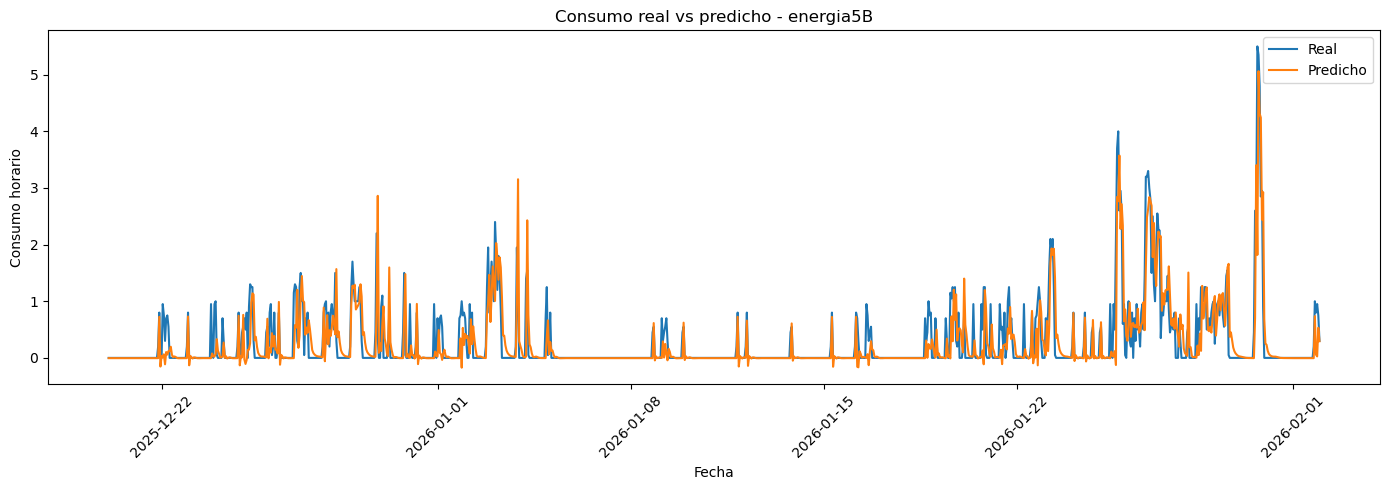

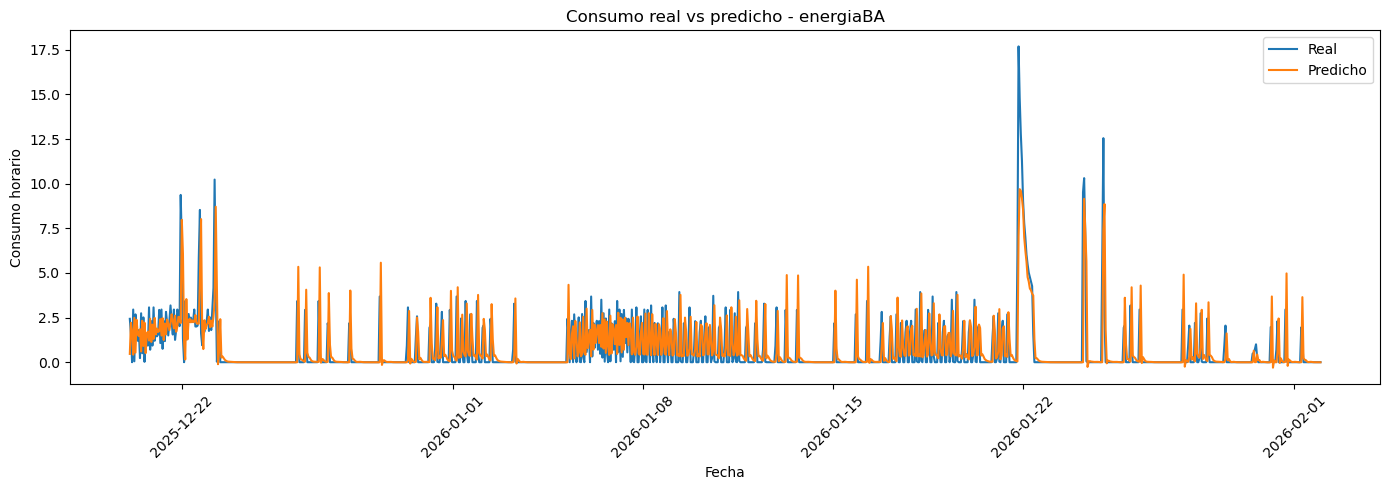

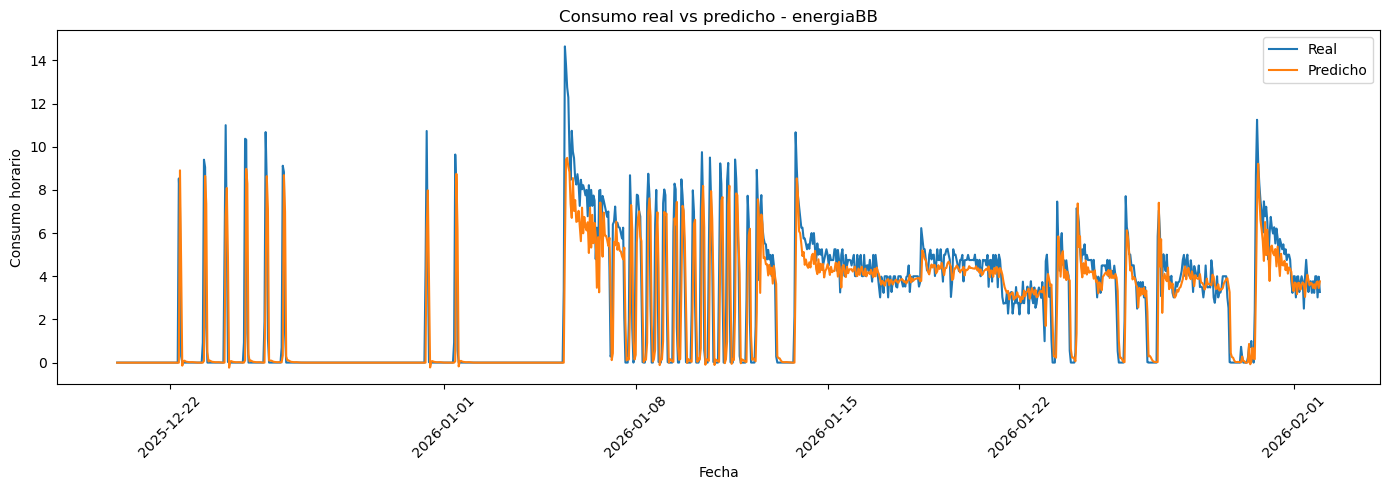

In [ ]:
# for vivienda in results_bilstm["vivienda"].unique():
#     r = results_bilstm[results_bilstm["vivienda"] == vivienda].copy()

#     plt.figure(figsize=(14,5))
#     plt.plot(r["fecha"], r["consumo"], label="Real")
#     plt.plot(r["fecha"], r["pred"], label="Predicho")
#     plt.title(f"Consumo real vs predicho - {vivienda}")
#     plt.xlabel("Fecha")
#     plt.ylabel("Consumo horario")
#     plt.legend()
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

### Modelo 5: LSTM

Train: (62744, 3)
Valid: (13442, 3)
Test: (13442, 3)
X_train: (60643, 168) y_train: (60643, 24)
X_valid: (11341, 168) y_valid: (11341, 24)
X_test : (11341, 168) y_test : (11341, 24)
Epoch 1/20 - train_loss: 0.2045 - valid_loss: 3.4270
Epoch 2/20 - train_loss: 0.1727 - valid_loss: 3.4234
Epoch 3/20 - train_loss: 0.1677 - valid_loss: 3.4910
Epoch 4/20 - train_loss: 0.1671 - valid_loss: 3.4593
Epoch 5/20 - train_loss: 0.1634 - valid_loss: 3.4492
Epoch 6/20 - train_loss: 0.1607 - valid_loss: 3.4748
Epoch 7/20 - train_loss: 0.1572 - valid_loss: 3.5219
Epoch 8/20 - train_loss: 0.1566 - valid_loss: 3.6050
Epoch 9/20 - train_loss: 0.1531 - valid_loss: 3.6708
Epoch 10/20 - train_loss: 0.1486 - valid_loss: 3.5634
Epoch 11/20 - train_loss: 0.1462 - valid_loss: 3.6405
Epoch 12/20 - train_loss: 0.1495 - valid_loss: 3.6259
Epoch 13/20 - train_loss: 0.1478 - valid_loss: 3.6394
Epoch 14/20 - train_loss: 0.1420 - valid_loss: 3.6274
Epoch 15/20 - train_loss: 0.1375 - valid_loss: 3.6647
Epoch 16/20 - tra

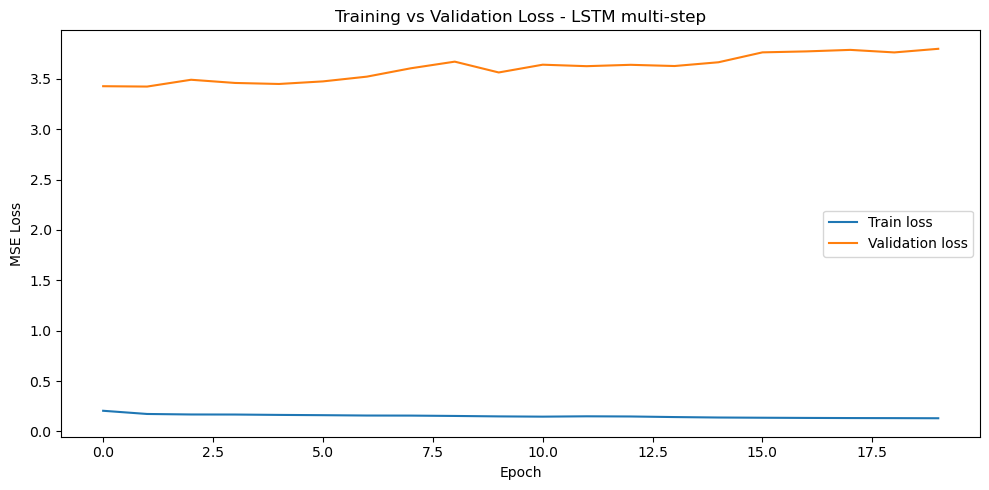

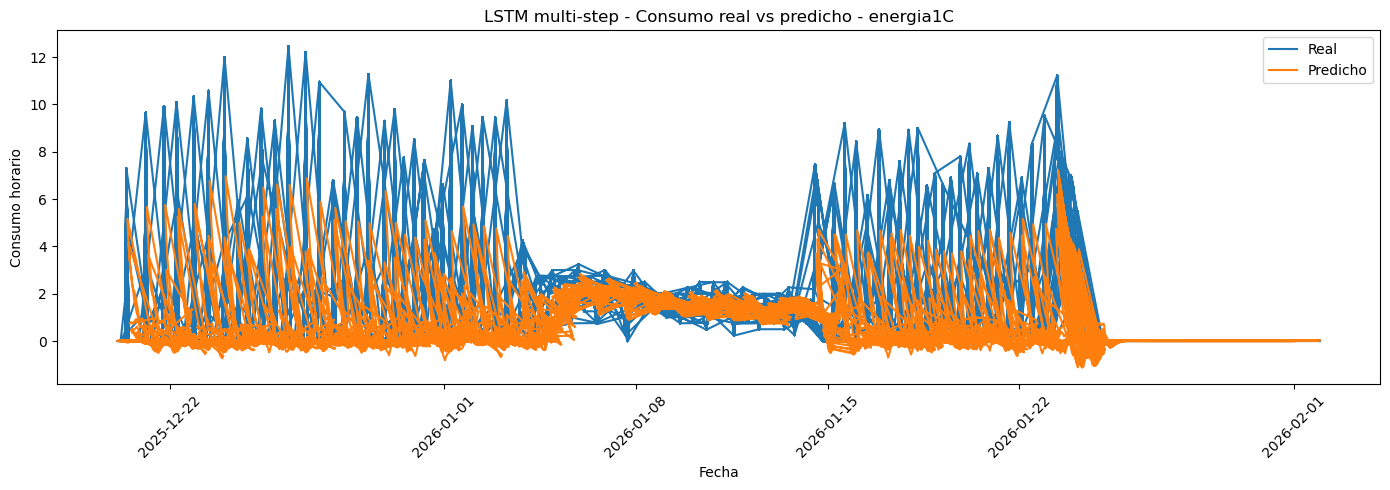

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# =========================================================
# 1. PARTIR DE df_long YA CREADO
# Debe tener al menos:
# fecha, vivienda, consumo
# =========================================================

df_lstm = df_long[["fecha", "vivienda", "consumo"]].copy()
df_lstm = df_lstm.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

# =========================================================
# 2. SPLIT TEMPORAL GLOBAL
# =========================================================

fechas_ordenadas = np.array(sorted(df_lstm["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train_df = df_lstm[df_lstm["fecha"] <= train_end].copy()
valid_df = df_lstm[(df_lstm["fecha"] > train_end) & (df_lstm["fecha"] <= valid_end)].copy()
test_df  = df_lstm[df_lstm["fecha"] > valid_end].copy()

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

# =========================================================
# 3. ESCALAR SOLO CON TRAIN
# =========================================================

scaler = StandardScaler()
scaler.fit(train_df[["consumo"]])

train_df["consumo_scaled"] = scaler.transform(train_df[["consumo"]])
valid_df["consumo_scaled"] = scaler.transform(valid_df[["consumo"]])
test_df["consumo_scaled"]  = scaler.transform(test_df[["consumo"]])

# =========================================================
# 4. CREAR SECUENCIAS MULTI-STEP POR VIVIENDA
# =========================================================

SEQ_LEN = 24 * 30      # 168 horas pasadas = 7 días
HORIZON = 24          # predecimos las próximas 24 horas

def make_sequences_multistep(df_part, seq_len=SEQ_LEN, horizon=HORIZON):
    X, y, fechas_inicio_pred, viviendas = [], [], [], []

    for vivienda, g in df_part.groupby("vivienda"):
        g = g.sort_values("fecha").reset_index(drop=True)

        values = g["consumo_scaled"].values
        fechas_g = g["fecha"].values

        # Necesitamos seq_len horas pasadas + horizon horas futuras
        if len(g) <= seq_len + horizon:
            continue

        for i in range(seq_len, len(g) - horizon + 1):
            # Input: últimas 168 horas
            X.append(values[i-seq_len:i])

            # Target: próximas 24 horas
            y.append(values[i:i+horizon])

            # Fecha de la primera hora predicha
            fechas_inicio_pred.append(fechas_g[i])
            viviendas.append(vivienda)

    X = np.array(X, dtype=np.float32)  # (N, 168)
    y = np.array(y, dtype=np.float32)  # (N, 24)

    fechas_inicio_pred = np.array(fechas_inicio_pred)
    viviendas = np.array(viviendas)

    return X, y, fechas_inicio_pred, viviendas

X_train, y_train, fechas_train, viv_train = make_sequences_multistep(train_df)
X_valid, y_valid, fechas_valid, viv_valid = make_sequences_multistep(valid_df)
X_test,  y_test,  fechas_test,  viv_test  = make_sequences_multistep(test_df)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

# =========================================================
# 5. DATASET / DATALOADER
# =========================================================

class SeqDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, seq_len)
        # y: (N, horizon)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32)                # (N, horizon)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SeqDataset(X_train, y_train)
valid_ds = SeqDataset(X_valid, y_valid)
test_ds  = SeqDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# =========================================================
# 6. MODELO LSTM MULTI-STEP
# =========================================================

class LSTMMultiStepModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2, horizon=24):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout
        )

        # Como NO es bidireccional, la salida tiene tamaño hidden_size, no hidden_size*2
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)

        # Usamos la última salida temporal como resumen de la secuencia pasada
        out = out[:, -1, :]

        # Devuelve 24 valores: próximas 24 horas
        out = self.fc(out)

        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_lstm_multi = LSTMMultiStepModel(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    horizon=HORIZON
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm_multi.parameters(), lr=0.001)

# =========================================================
# 7. ENTRENAMIENTO
# =========================================================

EPOCHS = 20
best_valid_loss = float("inf")
best_state = None

train_history = []
valid_history = []

for epoch in range(EPOCHS):
    model_lstm_multi.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        pred = model_lstm_multi(xb)  # (batch, 24)
        loss = criterion(pred, yb)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model_lstm_multi.eval()
    valid_losses = []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model_lstm_multi(xb)
            loss = criterion(pred, yb)

            valid_losses.append(loss.item())

    mean_train = np.mean(train_losses)
    mean_valid = np.mean(valid_losses)

    train_history.append(mean_train)
    valid_history.append(mean_valid)

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {mean_train:.4f} - valid_loss: {mean_valid:.4f}")

    if mean_valid < best_valid_loss:
        best_valid_loss = mean_valid
        best_state = model_lstm_multi.state_dict()

# Cargar mejor modelo
model_lstm_multi.load_state_dict(best_state)

# =========================================================
# 8. EVALUACIÓN EN TEST
# =========================================================

model_lstm_multi.eval()
preds_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        pred = model_lstm_multi(xb).cpu().numpy()  # (batch, 24)
        preds_scaled.append(pred)

preds_scaled = np.vstack(preds_scaled)  # (N, 24)

# Desescalar y_test y predicciones
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
preds_real = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape)

# Métricas globales sobre todas las horas predichas
mae_lstm_multi = mean_absolute_error(y_test_real.flatten(), preds_real.flatten())
rmse_lstm_multi = np.sqrt(mean_squared_error(y_test_real.flatten(), preds_real.flatten()))

print("LSTM multi-step MAE:", mae_lstm_multi)
print("LSTM multi-step RMSE:", rmse_lstm_multi)

# =========================================================
# 9. RESULTADOS EN FORMATO LARGO
# =========================================================

rows = []

for sample_idx in range(len(preds_real)):
    vivienda = viv_test[sample_idx]
    fecha_inicio = pd.to_datetime(fechas_test[sample_idx])

    for h in range(HORIZON):
        rows.append({
            "vivienda": vivienda,
            "fecha_pred": fecha_inicio + pd.Timedelta(hours=h),
            "horizon_hour": h + 1,
            "consumo": y_test_real[sample_idx, h],
            "pred": preds_real[sample_idx, h]
        })

results_lstm_multi = pd.DataFrame(rows)

print(results_lstm_multi.head())

# =========================================================
# 10. MÉTRICAS POR HORIZONTE
# =========================================================

metricas_por_horizonte = (
    results_lstm_multi.groupby("horizon_hour")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["consumo"], g["pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["consumo"], g["pred"]))
    }))
)

print("\nMétricas por hora del horizonte:")
print(metricas_por_horizonte)

# =========================================================
# 11. MÉTRICAS POR VIVIENDA
# =========================================================

metricas_por_vivienda_lstm_multi = (
    results_lstm_multi.groupby("vivienda")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["consumo"], g["pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["consumo"], g["pred"]))
    }))
    .sort_values("MAE")
)

print("\nMétricas por vivienda:")
print(metricas_por_vivienda_lstm_multi)

# =========================================================
# 12. GRÁFICA TRAIN VS VALID LOSS
# =========================================================

plt.figure(figsize=(10, 5))
plt.plot(train_history, label="Train loss")
plt.plot(valid_history, label="Validation loss")
plt.title("Training vs Validation Loss - LSTM multi-step")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 13. GRÁFICA DE UNA VIVIENDA
# =========================================================

vivienda_ejemplo = "energia1C"

r = results_lstm_multi[results_lstm_multi["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14, 5))
plt.plot(r["fecha_pred"], r["consumo"], label="Real")
plt.plot(r["fecha_pred"], r["pred"], label="Predicho")
plt.title(f"LSTM multi-step - Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
metricas

{'Modelo 1: XGBoost base': {'train': {'MAE': 0.039070052909640364,
   'RMSE': 0.12792624308280692,
   'R2': 0.9731307710861002},
  'test': {'MAE': 0.4796160015164177,
   'RMSE': 1.108359779968516,
   'R2': 0.540462428498428}},
 'Modelo2: XGBoost con más lags': {'train': {'MAE': 0.05237696252851894,
   'RMSE': 0.17942997638657512,
   'R2': 0.9471401517859614},
  'test': {'MAE': 0.43804657431757077,
   'RMSE': 1.0813892204224498,
   'R2': 0.5625548745273177}},
 'Modelo3: XGBoost + temperatura': {'train': {'MAE': 0.05237312352791274,
   'RMSE': 0.1772982003589763,
   'R2': 0.9483887275483224},
  'test': {'MAE': 0.4591515473007066,
   'RMSE': 1.076414098090734,
   'R2': 0.5665707027715714}},
 'BiLSTM': {'train': {'MAE': 0.05285321921110153,
   'RMSE': 0.20947890728068658,
   'R2': 0.9285472631454468},
  'test': {'MAE': 0.44046884775161743,
   'RMSE': 1.1090266795754429,
   'R2': 0.5559305548667908}}}

MODELO BASE USANDO- seasonal naïve method

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# =========================================================
# BASELINE NAIVE SEMANAL
# pred(t) = consumo(t - 168)
# =========================================================

df_baseline = df_long[["fecha", "vivienda", "consumo"]].copy()
df_baseline = df_baseline.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

# Predicción naive semanal: misma hora de la semana anterior
df_baseline["pred_naive_week"] = (
    df_baseline.groupby("vivienda")["consumo"].shift(168)
)

# Eliminar filas sin predicción
df_baseline = df_baseline.dropna().copy()

# =========================================================
# SPLIT TEMPORAL 70/15/15
# =========================================================

fechas_ordenadas = np.array(sorted(df_baseline["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train_baseline = df_baseline[df_baseline["fecha"] <= train_end].copy()
valid_baseline = df_baseline[
    (df_baseline["fecha"] > train_end) &
    (df_baseline["fecha"] <= valid_end)
].copy()
test_baseline = df_baseline[df_baseline["fecha"] > valid_end].copy()

# =========================================================
# Y REAL / Y PRED TRAIN Y TEST
# =========================================================

y_train_naive = train_baseline["consumo"]
y_pred_train_naive = train_baseline["pred_naive_week"]

y_test_naive = test_baseline["consumo"]
y_pred_test_naive = test_baseline["pred_naive_week"]

# =========================================================
# GUARDAR MÉTRICAS CON TU FUNCIÓN
# =========================================================

metricas = guardar_metricas_modelo(
    nombre_modelo="Naive semanal",
    y_train=y_train_naive,
    y_pred_train=y_pred_train_naive,
    y_test=y_test_naive,
    y_pred_test=y_pred_test_naive,
    metricas_modelos=metricas
)

metricas

{'Naive diario': {'train': {'MAE': 0.10350672186965336,
   'RMSE': 0.4559345663449269,
   'R2': 0.6996127584358403},
  'test': {'MAE': 0.7706038214659516,
   'RMSE': 1.8419676855121425,
   'R2': -0.2760168325410466}},
 'Naive semanal': {'train': {'MAE': 0.1661307906341006,
   'RMSE': 0.6321561775951859,
   'R2': 0.34387787249741264},
  'test': {'MAE': 0.8805708422013202,
   'RMSE': 1.9359564016566557,
   'R2': -0.402008525505545}}}

Modelo base- naive diario

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# =========================================================
# BASELINE NAIVE DIARIO
# pred(t) = consumo(t - 24)
# =========================================================

df_baseline_dia = df_long[["fecha", "vivienda", "consumo"]].copy()
df_baseline_dia = df_baseline_dia.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

# Predicción naive diaria: misma hora del día anterior
df_baseline_dia["pred_naive_day"] = (
    df_baseline_dia.groupby("vivienda")["consumo"].shift(24)
)

# Eliminar filas sin predicción por falta de histórico
df_baseline_dia = df_baseline_dia.dropna().copy()

# =========================================================
# SPLIT TEMPORAL 70/15/15
# =========================================================

fechas_ordenadas = np.array(sorted(df_baseline_dia["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train_baseline_dia = df_baseline_dia[df_baseline_dia["fecha"] <= train_end].copy()

valid_baseline_dia = df_baseline_dia[
    (df_baseline_dia["fecha"] > train_end) &
    (df_baseline_dia["fecha"] <= valid_end)
].copy()

test_baseline_dia = df_baseline_dia[
    df_baseline_dia["fecha"] > valid_end
].copy()

# =========================================================
# Y REAL / Y PRED TRAIN Y TEST
# =========================================================

y_train_naive_day = train_baseline_dia["consumo"]
y_pred_train_naive_day = train_baseline_dia["pred_naive_day"]

y_test_naive_day = test_baseline_dia["consumo"]
y_pred_test_naive_day = test_baseline_dia["pred_naive_day"]

# =========================================================
# GUARDAR MÉTRICAS CON TU FUNCIÓN
# =========================================================

metricas = guardar_metricas_modelo(
    nombre_modelo="Naive diario",
    y_train=y_train_naive_day,
    y_pred_train=y_pred_train_naive_day,
    y_test=y_test_naive_day,
    y_pred_test=y_pred_test_naive_day,
    metricas_modelos=metricas
)

metricas["Naive diario"]

{'train': {'MAE': 0.10350672186965336,
  'RMSE': 0.4559345663449269,
  'R2': 0.6996127584358403},
 'test': {'MAE': 0.7706038214659516,
  'RMSE': 1.8419676855121425,
  'R2': -0.2760168325410466}}

In [31]:
metricas

{'Naive diario': {'train': {'MAE': 0.10350672186965336,
   'RMSE': 0.4559345663449269,
   'R2': 0.6996127584358403},
  'test': {'MAE': 0.7706038214659516,
   'RMSE': 1.8419676855121425,
   'R2': -0.2760168325410466}}}

### Con chronos preentrenado -> Va fatal

### Modelo XGBoost a 7 días (Next-Week Forecasting)
Como predecir 30 días hacia el futuro de forma recursiva acumula mucho error (error propagation), vamos a evaluar el rendimiento del modelo si reducimos el horizonte a solo 7 días (168 horas). Este horizonte es mucho más realista para un entorno de producción donde queremos optimizar la tarifa de la semana que viene.

Métricas globales para horizonte de 7 DÍAS:
MAE 7 días: 0.4454745248592713
RMSE 7 días: 1.0783838292823813

Métricas por vivienda (7 días):
                MAE      RMSE
vivienda                     
energia2B  0.007263  0.007263
energia3A  0.007263  0.007263
energia5B  0.049570  0.146324
energia3B  0.149812  0.652018
energia5A  0.248658  0.410955
energia2A  0.268258  0.337147
energia4B  0.282408  0.428896
energia1C  0.633039  1.745962
energia4A  0.770897  1.562119
energiaBB  1.048838  1.888373
energiaBA  1.434215  1.680575


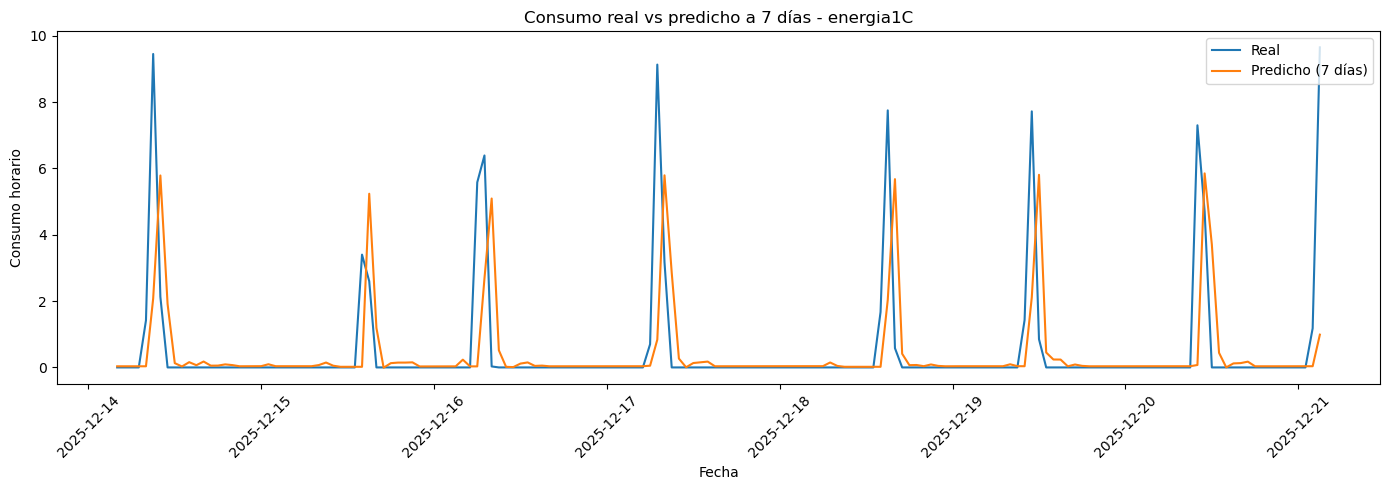

In [ ]:
# Vamos a usar el mismo modelo entrenado (model1 o model2) pero evaluarlo a 168 horas.
# Seleccionamos el test set original pero limitamos la evaluación a los primeros 7 días.
HORIZON_7D = 24 * 7

results_7d = []

for vivienda in test["vivienda"].unique():
    r = test[test["vivienda"] == vivienda].copy().sort_values("fecha")
    if len(r) > HORIZON_7D:
        r = r.iloc[:HORIZON_7D]
    
    X_test_7d = r[features]
    y_test_7d = r[target]
    
    # Usaremos el model2 (XGBoost con lags extra) que ya está entrenado
    y_pred_7d = model2.predict(X_test_7d)
    
    r["pred_7d"] = y_pred_7d
    results_7d.append(r)

results_7d_df = pd.concat(results_7d)

mae_7d = mean_absolute_error(results_7d_df[target], results_7d_df["pred_7d"])
rmse_7d = np.sqrt(mean_squared_error(results_7d_df[target], results_7d_df["pred_7d"]))

print("Métricas globales para horizonte de 7 DÍAS:")
print("MAE 7 días:", mae_7d)
print("RMSE 7 días:", rmse_7d)

metricas_7d_vivienda = (
    results_7d_df.groupby("vivienda")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g[target], g["pred_7d"]),
        "RMSE": np.sqrt(mean_squared_error(g[target], g["pred_7d"]))
    }))
    .sort_values("MAE")
)
print("\nMétricas por vivienda (7 días):")
print(metricas_7d_vivienda)

# Visualizar la primera vivienda a 7 días
vivienda_ejemplo = "energia1C"
r_vis = results_7d_df[results_7d_df["vivienda"] == vivienda_ejemplo]

plt.figure(figsize=(14,5))
plt.plot(r_vis["fecha"], r_vis[target], label="Real")
plt.plot(r_vis["fecha"], r_vis["pred_7d"], label="Predicho (7 días)")
plt.title(f"Consumo real vs predicho a 7 días - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
